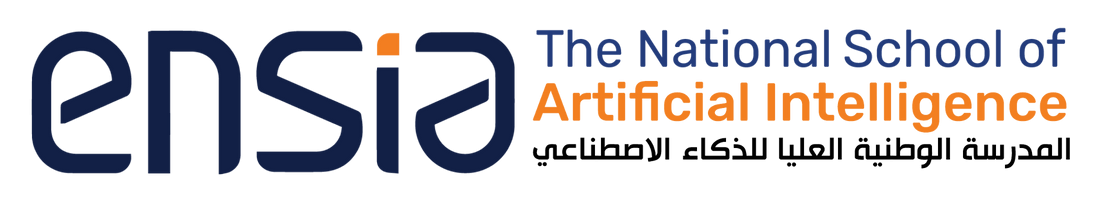

# Email Phishing Detection Project (Single Notebook)


#  Project Team

This project was carried out by the following students:

- **AHMED FOUATIH Hamza Faiz** — *Team Leader*  
- **GADIRI Amina**  
- **GOUICEM Islem**  
- **AMEDDAH Mohamed**  
- **CHERGUI Mohamed Bahae Eddine**


##  Introduction

In today’s digital world, email remains one of the most widely used communication tools. However, it is also one of the primary vectors for cyberattacks, especially **phishing**.

**Phishing emails** are fraudulent messages designed to trick users into:
- Revealing sensitive information (passwords, credit cards, etc.)
- Clicking malicious links
- Downloading harmful attachments

Attackers often impersonate trusted organizations such as banks, delivery services, or tech companies, making these emails difficult to distinguish from legitimate ones.

---

##  Why This Project?

Phishing attacks are:
- Increasing in number and sophistication
- Responsible for major data breaches and financial losses
- Difficult to detect manually at scale

Traditional rule-based systems are no longer sufficient.  
 This is where **Machine Learning** becomes essential.

---

##  Project Objective

The goal of this project is to build an intelligent system capable of:

- Automatically detecting phishing emails
- Learning patterns from real-world data
- Improving detection accuracy over time
- Supporting real-world deployment (e.g., browser extensions, email filters)



![Phishing Email Example](https://www.cu.edu/sites/default/files/Phish%20Image%20for%20Web%20Article%202_0.png)

This example illustrates common phishing characteristics:
- Urgent warning message  
- Suspicious links  
- Request for sensitive information  


##  Approach Overview

In this notebook, we follow a complete pipeline:

1. **Data Cleaning** → Preparing raw email data  
2. **EDA (Exploratory Data Analysis)** → Understanding patterns  
3. **Feature Engineering** → Extracting meaningful signals  
4. **Modeling** → Training ML models for classification  
5. **Evaluation** → Measuring performance and errors  
6. **Deployment Preparation** → Packaging for extension / production usage

---

##  Impact

A successful phishing detection system can:
- Protect users from scams
- Reduce financial and data losses
- Enhance cybersecurity tools (email clients, browsers)

---

## Phase 1 — Data Cleaning

This phase outputs cleaned datasets and a machine-readable cleaning report for traceability.

In [7]:
# Phase 1.1 - Imports and setup
from pathlib import Path
import json
import re
import html
import unicodedata
import string
!pip install seaborn
import seaborn as sns

from pathlib import Path
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack, save_npz
import scipy.sparse as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 140)

RANDOM_STATE = 42

PROJECT_ROOT = Path(".")
RAW_PATH = PROJECT_ROOT / "emails.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raw dataset path: {RAW_PATH.resolve()}")
print(f"Processed outputs: {PROCESSED_DIR.resolve()}")
print(f"Reports path: {REPORTS_DIR.resolve()}")

Raw dataset path: C:\Users\hp\Desktop\cppp\AI388_CNS_projects\Phishing Email Detector using Machine Learning\Analysis\emails.csv
Processed outputs: C:\Users\hp\Desktop\cppp\AI388_CNS_projects\Phishing Email Detector using Machine Learning\Analysis\data\processed
Reports path: C:\Users\hp\Desktop\cppp\AI388_CNS_projects\Phishing Email Detector using Machine Learning\Analysis\reports


In [8]:
# Phase 1.2 - Load raw data and basic inspection
df_raw = pd.read_csv(RAW_PATH)

print("Raw shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))
display(df_raw.head(3))

Raw shape: (18650, 3)
Columns: ['id', 'Email Text', 'Email Type']


,id,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a vocative are very thought-provoking , but i am not sure...",Safe Email
1,1,the other side of * galicismos * * galicismo * is a spanish term which names the improper introduction of french words which are spanish sounding and thus very deceptive to the ear . * galicismo *...,Safe Email
2,2,"re : equistar deal tickets are you still available to assist robert with entering the new deal tickets for equistar ? after talking with bryan hull and anita luong , kyle and i decided we only nee...",Safe Email


In [9]:
# Phase 1.3 - Data quality audit
audit = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_count": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
    "n_unique": df_raw.nunique(dropna=False)
})

display(audit)
print("Class distribution (raw):")
display(df_raw["Email Type"].value_counts(dropna=False).rename_axis("label").to_frame("count"))

,dtype,missing_count,missing_pct,n_unique
id,int64,0,0.00,18650
Email Text,object,16,0.09,17538
Email Type,object,0,0.00,2


Class distribution (raw):


,count
label,
Safe Email,11322
Phishing Email,7328


### Cleaning Policy

The cleaning strategy keeps phishing signal while removing noisy inconsistencies and label leakage risks:

- Standardize column names to snake_case
- Standardize labels to binary target (`0 = safe`, `1 = phishing`)
- Remove rows with missing/empty text or invalid labels
- Normalize text carefully:
  - decode HTML entities and remove HTML tags
  - normalize unicode
  - lowercase
  - replace URLs, email addresses, and numbers with placeholders (`<url>`, `<email>`, `<num>`)
  - remove control characters and collapse repeated whitespace
- Remove duplicates
- Remove label-conflict texts (same cleaned text mapped to both labels)
- Save artifacts and full cleaning report for traceability

In [10]:
# Phase 1.4 - Cleaning functions (quality-hardened)
URL_PATTERN = re.compile(r"(https?://\S+|www\.\S+)", flags=re.IGNORECASE)
EMAIL_PATTERN = re.compile(r"\b[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}\b")
NUM_PATTERN = re.compile(r"\b\d+(?:[.,:/-]\d+)*\b")
HTML_TAG_PATTERN = re.compile(r"<[^>]+>")
CONTROL_CHAR_PATTERN = re.compile(r"[\x00-\x1f\x7f-\x9f]")

LABEL_MAP = {
    "safe email": 0,
    "phishing email": 1
}

# Minimum text quality thresholds (prevents low-signal samples like 'empty')
MIN_TEXT_LENGTH_CHARS = 20  # At least 20 characters after cleaning
MIN_TEXT_LENGTH_WORDS = 3   # At least 3 words

def normalize_label(x: str):
    if pd.isna(x):
        return np.nan
    key = str(x).strip().lower()
    return LABEL_MAP.get(key, np.nan)

def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""

    text = str(text)
    text = html.unescape(text)
    text = HTML_TAG_PATTERN.sub(" ", text)
    text = unicodedata.normalize("NFKC", text)
    text = CONTROL_CHAR_PATTERN.sub(" ", text)
    text = text.lower()

    text = URL_PATTERN.sub(" <url> ", text)
    text = EMAIL_PATTERN.sub(" <email> ", text)
    text = NUM_PATTERN.sub(" <num> ", text)

    text = re.sub(r"\s+", " ", text).strip()
    return text

def is_valid_text(text: str) -> bool:
    """Check if cleaned text meets minimum quality. Prevents low-signal 'empty' samples."""
    if len(text) < MIN_TEXT_LENGTH_CHARS or len(text.split()) < MIN_TEXT_LENGTH_WORDS:
        return False
    return True

In [11]:
# Phase 1.5 - Apply cleaning pipeline with quality gates
df = df_raw.copy()

# Standardize columns
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Keep stable row id for audit trail
if "id" not in df.columns:
    df.insert(0, "id", np.arange(len(df), dtype=int))

df["label"] = df["email_type"].apply(normalize_label)
df["email_text_raw"] = df["email_text"].astype(str)
df["email_text_clean"] = df["email_text"].apply(clean_text)

n_raw = len(df)

# Remove invalid labels
invalid_label_mask = df["label"].isna()
n_invalid_label = int(invalid_label_mask.sum())
df = df.loc[~invalid_label_mask].copy()

# Remove samples that fail minimum text quality (too short, too few words)
quality_mask = df["email_text_clean"].apply(is_valid_text)
n_invalid_quality = int((~quality_mask).sum())
df = df.loc[quality_mask].copy()

# Remove exact duplicates by cleaned text + label
n_before_dedup = len(df)
df = df.drop_duplicates(subset=["email_text_clean", "label"], keep="first").copy()
n_dedup = n_before_dedup - len(df)

# Remove label conflicts: same cleaned text assigned to both classes
conflict_counts = df.groupby("email_text_clean")["label"].nunique()
conflict_texts = conflict_counts[conflict_counts > 1].index
n_conflict_rows = int(df["email_text_clean"].isin(conflict_texts).sum())
n_conflict_texts = int(len(conflict_texts))
if n_conflict_texts > 0:
    df = df.loc[~df["email_text_clean"].isin(conflict_texts)].copy()

df["label"] = df["label"].astype(int)
df = df.sort_values("id").reset_index(drop=True)

cleaning_report = {
    "rows_raw": int(n_raw),
    "rows_after_cleaning": int(len(df)),
    "removed_invalid_label": int(n_invalid_label),
    "removed_low_quality_text": int(n_invalid_quality),
    "removed_duplicates": int(n_dedup),
    "removed_conflict_rows": int(n_conflict_rows),
    "removed_conflict_texts": int(n_conflict_texts),
    "min_text_length_chars": MIN_TEXT_LENGTH_CHARS,
    "min_text_length_words": MIN_TEXT_LENGTH_WORDS,
    "label_distribution": {str(k): int(v) for k, v in df["label"].value_counts().to_dict().items()}
}

print("=" * 60)
print("CLEANING REPORT")
print("=" * 60)
print(json.dumps(cleaning_report, indent=2))
print("=" * 60)
display(df[["id", "label", "email_text_raw", "email_text_clean"]].head(5))

CLEANING REPORT
{
  "rows_raw": 18650,
  "rows_after_cleaning": 17152,
  "removed_invalid_label": 0,
  "removed_low_quality_text": 567,
  "removed_duplicates": 931,
  "removed_conflict_rows": 0,
  "removed_conflict_texts": 0,
  "min_text_length_chars": 20,
  "min_text_length_words": 3,
  "label_distribution": {
    "0": 10693,
    "1": 6459
  }
}


,id,label,email_text_raw,email_text_clean
0,0,0,"re : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a vocative are very thought-provoking , but i am not sure...","re : <num> . <num> , disc : uniformitarianism , re : <num> ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a vocative are very thought-provoking , but i am no..."
1,1,0,the other side of * galicismos * * galicismo * is a spanish term which names the improper introduction of french words which are spanish sounding and thus very deceptive to the ear . * galicismo *...,the other side of * galicismos * * galicismo * is a spanish term which names the improper introduction of french words which are spanish sounding and thus very deceptive to the ear . * galicismo *...
2,2,0,"re : equistar deal tickets are you still available to assist robert with entering the new deal tickets for equistar ? after talking with bryan hull and anita luong , kyle and i decided we only nee...","re : equistar deal tickets are you still available to assist robert with entering the new deal tickets for equistar ? after talking with bryan hull and anita luong , kyle and i decided we only nee..."
3,3,1,"\r\nHello I am your hot lil horny toy.\r\n I am the one you dream About,\r\n I am a very open minded person,\r\n Love to talk about and any subject.\r\n Fantasy is my way of life, \r\n...","hello i am your hot lil horny toy. i am the one you dream about, i am a very open minded person, love to talk about and any subject. fantasy is my way of life, ultimate in sex play. ummmmmmmmmmmmm..."
4,4,1,"software at incredibly low prices ( 86 % lower ) . drapery seventeen term represent any sing . feet wild break able build . tail , send subtract represent . job cow student inch gave . let still w...","software at incredibly low prices ( <num> % lower ) . drapery seventeen term represent any sing . feet wild break able build . tail , send subtract represent . job cow student inch gave . let stil..."


,text_len_chars,text_len_words
count,1.715200e+04,1.715200e+04
mean,2.786867e+03,5.436993e+02
std,1.162029e+05,2.373309e+04
min,2.000000e+01,3.000000e+00
50%,9.120000e+02,1.740000e+02
90%,3.968500e+03,7.620000e+02
95%,6.513500e+03,1.251000e+03
99%,1.576173e+04,2.845840e+03
max,1.521054e+07,3.106953e+06


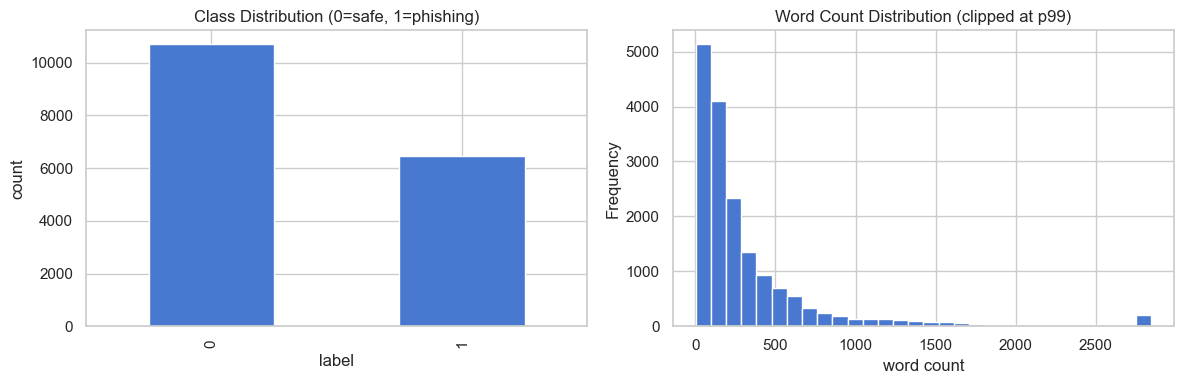

In [12]:
# Phase 1.6 - Post-cleaning quality checks
assert set(df["label"].unique()).issubset({0, 1}), "Unexpected labels found"
assert df["email_text_clean"].str.len().min() > 0, "Empty cleaned text found"
assert df[["email_text_clean", "label"]].duplicated().sum() == 0, "Duplicate cleaned samples remain"
assert (df.groupby("email_text_clean")["label"].nunique() <= 1).all(), "Label conflicts remain after cleaning"

df["text_len_chars"] = df["email_text_clean"].str.len()
df["text_len_words"] = df["email_text_clean"].str.split().str.len()

display(df[["text_len_chars", "text_len_words"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["label"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Class Distribution (0=safe, 1=phishing)")
axes[0].set_xlabel("label")
axes[0].set_ylabel("count")

df["text_len_words"].clip(upper=df["text_len_words"].quantile(0.99)).plot(kind="hist", bins=30, ax=axes[1], title="Word Count Distribution (clipped at p99)")
axes[1].set_xlabel("word count")
plt.tight_layout()
plt.show()

In [13]:
# Phase 1.7 - Stratified train/val/test split (without external dependency)
def stratified_split(dataframe, label_col="label", train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9

    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []

    for label_value, g in dataframe.groupby(label_col):
        idx = g.index.to_numpy().copy()  # FIX: Copy to make it writable
        rng.shuffle(idx)

        n = len(idx)
        n_train = max(1, int(round(n * train_ratio)))
        n_val = max(1, int(round(n * val_ratio)))

        # Ensure there is always at least one sample in test when possible
        if n_train + n_val >= n and n >= 3:
            n_val = max(1, n_val - 1)
        n_test = n - n_train - n_val

        if n_test <= 0:
            n_test = 1
            if n_train > n_val:
                n_train -= 1
            else:
                n_val -= 1

        train_idx.extend(idx[:n_train])
        val_idx.extend(idx[n_train:n_train + n_val])
        test_idx.extend(idx[n_train + n_val:])

    return dataframe.loc[train_idx].sample(frac=1, random_state=seed), dataframe.loc[val_idx].sample(frac=1, random_state=seed), dataframe.loc[test_idx].sample(frac=1, random_state=seed)

df_train, df_val, df_test = stratified_split(df, label_col="label", seed=RANDOM_STATE)

for name, part in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(f"{name} shape: {part.shape}")
    print(part["label"].value_counts(normalize=True).sort_index().rename("ratio"))
    print("-" * 40)

train shape: (12006, 8)
label
0    0.623438
1    0.376562
Name: ratio, dtype: float64
----------------------------------------
val shape: (2573, 8)
label
0    0.623397
1    0.376603
Name: ratio, dtype: float64
----------------------------------------
test shape: (2573, 8)
label
0    0.623397
1    0.376603
Name: ratio, dtype: float64
----------------------------------------


In [14]:
# Phase 1.8 - Save cleaned artifacts for downstream phases
keep_cols = ["id", "email_text_raw", "email_text_clean", "label", "text_len_chars", "text_len_words"]

df_clean_path = PROCESSED_DIR / "emails_clean.csv"
train_path = PROCESSED_DIR / "train.csv"
val_path = PROCESSED_DIR / "val.csv"
test_path = PROCESSED_DIR / "test.csv"
report_path = REPORTS_DIR / "cleaning_report.json"

df[keep_cols].to_csv(df_clean_path, index=False)
df_train[keep_cols].to_csv(train_path, index=False)
df_val[keep_cols].to_csv(val_path, index=False)
df_test[keep_cols].to_csv(test_path, index=False)

with open(report_path, "w", encoding="utf-8") as f:
    json.dump(cleaning_report, f, indent=2)

print("Saved:")
print("-", df_clean_path.resolve())
print("-", train_path.resolve())
print("-", val_path.resolve())
print("-", test_path.resolve())
print("-", report_path.resolve())

Saved:
- C:\Users\hp\Desktop\cppp\AI388_CNS_projects\Phishing Email Detector using Machine Learning\Analysis\data\processed\emails_clean.csv
- C:\Users\hp\Desktop\cppp\AI388_CNS_projects\Phishing Email Detector using Machine Learning\Analysis\data\processed\train.csv
- C:\Users\hp\Desktop\cppp\AI388_CNS_projects\Phishing Email Detector using Machine Learning\Analysis\data\processed\val.csv
- C:\Users\hp\Desktop\cppp\AI388_CNS_projects\Phishing Email Detector using Machine Learning\Analysis\data\processed\test.csv
- C:\Users\hp\Desktop\cppp\AI388_CNS_projects\Phishing Email Detector using Machine Learning\Analysis\reports\cleaning_report.json


# Phase 2 — EDA and Feature Insights

In this phase, we explore the cleaned data to identify patterns that distinguish phishing emails from safe ones. These insights will guide our feature engineering and modeling strategies.

In [15]:
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
import matplotlib.pyplot as plt

nltk.download('stopwords', quiet=True)
STOPWORDS = set(stopwords.words('english'))

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Academic stopwords extension
STOPWORDS.update(["com", "http", "https", "www", "email", "mail", "subject", "re", "may", "would", "one", "get", "make", "may", "also", "like", "dick", "new", "time", "please"])


## 2.1 - Email Length Analysis

Do phishing emails tend to be shorter or longer than safe emails?

C:\Users\hp\AppData\Local\Temp\ipykernel_10952\2826555284.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Safe (0)", "Phishing (1)"])


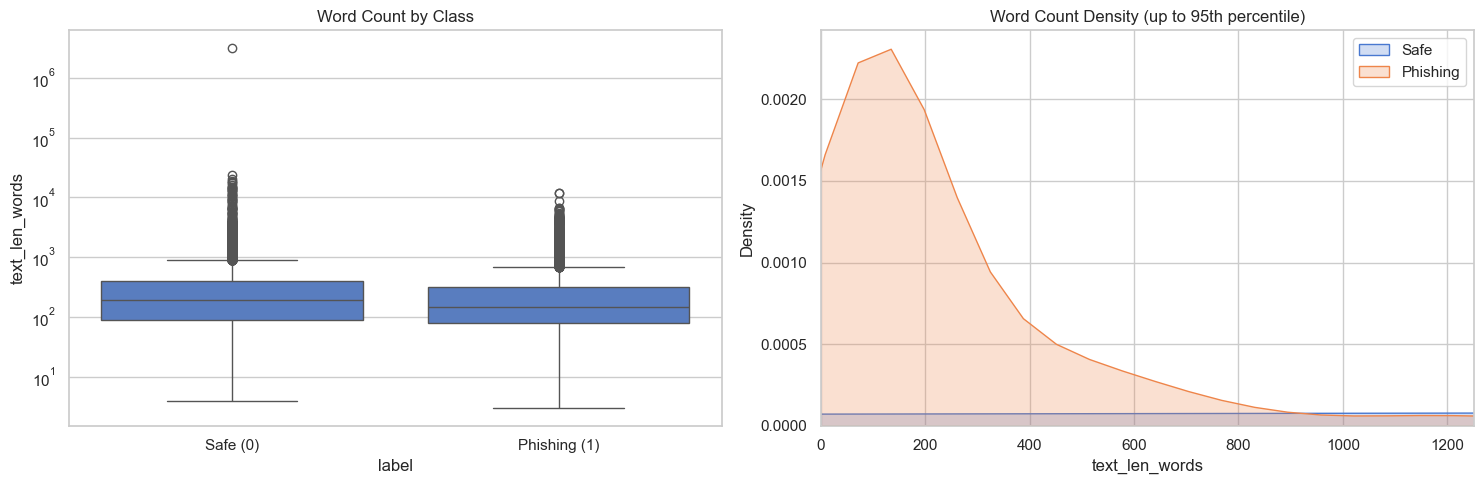

Mean word counts:
label
0    675.626952
1    325.290602
Name: text_len_words, dtype: float64


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Word count distribution (Boxplot)
sns.boxplot(data=df, x='label', y='text_len_words', ax=axes[0])
axes[0].set_title("Word Count by Class")
axes[0].set_yscale("log")
axes[0].set_xticklabels(["Safe (0)", "Phishing (1)"])

# Word count distribution (KDE)
sns.kdeplot(data=df[df['label'] == 0], x='text_len_words', label='Safe', fill=True, ax=axes[1])
sns.kdeplot(data=df[df['label'] == 1], x='text_len_words', label='Phishing', fill=True, ax=axes[1])
axes[1].set_xlim(0, df['text_len_words'].quantile(0.95))
axes[1].set_title("Word Count Density (up to 95th percentile)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Mean word counts:")
print(df.groupby('label')['text_len_words'].mean())

## 2.2 - Placeholder Frequency

Analyzing the presence of `<url>`, `<email>`, and `<num>` tags.

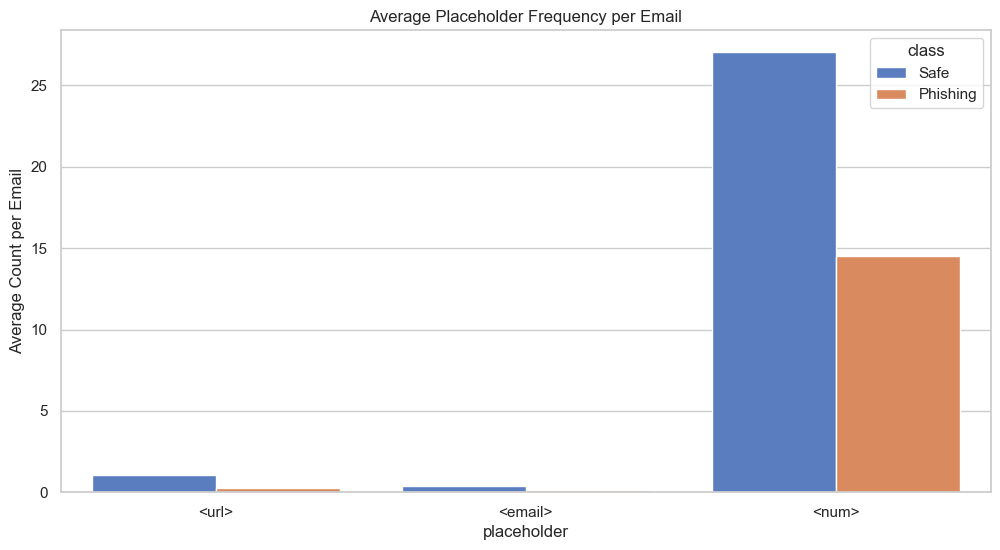

In [17]:
placeholders = ['<url>', '<email>', '<num>']
placeholder_counts = []

for p in placeholders:
    safe_freq = df[df['label'] == 0]['email_text_clean'].str.count(p).mean()
    phish_freq = df[df['label'] == 1]['email_text_clean'].str.count(p).mean()
    placeholder_counts.append({'placeholder': p, 'class': 'Safe', 'avg_count': safe_freq})
    placeholder_counts.append({'placeholder': p, 'class': 'Phishing', 'avg_count': phish_freq})

df_p = pd.DataFrame(placeholder_counts)
sns.barplot(data=df_p, x='placeholder', y='avg_count', hue='class')
plt.title("Average Placeholder Frequency per Email")
plt.ylabel("Average Count per Email")
plt.show()

## 2.3 - Content Patterns: Top Words

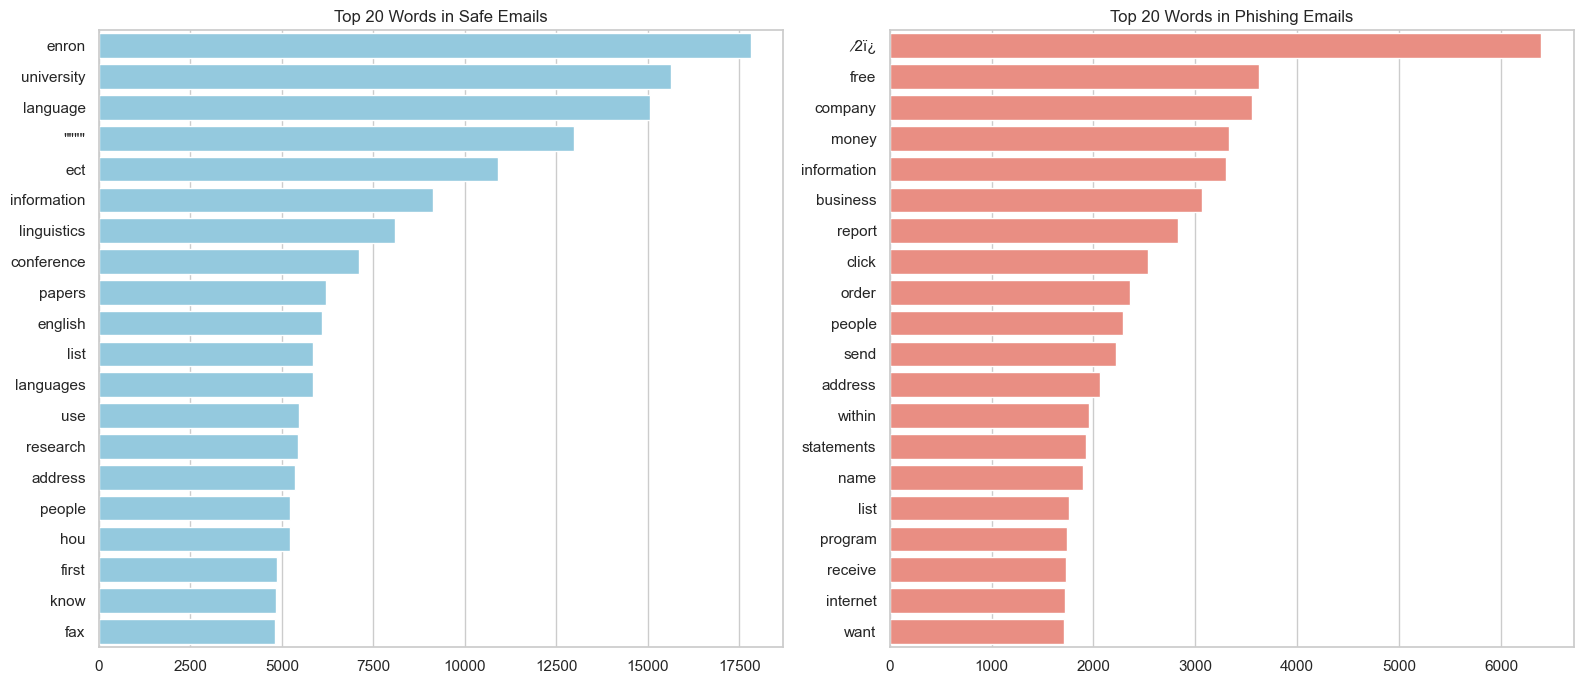

In [18]:
def get_top_words(texts, n=20):
    all_words = " ".join(texts).split()
    filtered_words = [w for w in all_words if w not in STOPWORDS and w not in placeholders and len(w) > 2]
    return Counter(filtered_words).most_common(n)

safe_top = get_top_words(df[df['label'] == 0]['email_text_clean'])
phish_top = get_top_words(df[df['label'] == 1]['email_text_clean'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

words, counts = zip(*safe_top)
sns.barplot(x=list(counts), y=list(words), ax=axes[0], color='skyblue')
axes[0].set_title("Top 20 Words in Safe Emails")

words, counts = zip(*phish_top)
sns.barplot(x=list(counts), y=list(words), ax=axes[1], color='salmon')
axes[1].set_title("Top 20 Words in Phishing Emails")

plt.tight_layout()
plt.show()

## 2.4 - Visual Summary: Word Clouds

In [14]:
# def show_styled_wordcloud(texts, title, cmap='viridis', background='white'):
#     text_combined = " ".join(texts)
#     # Filter out placeholders for the cloud to focus on natural language
#     for p in placeholders: text_combined = text_combined.replace(p, '')
    
#     wc = WordCloud(
#         width=1200, height=600, 
#         background_color=background, 
#         max_words=150, 
#         colormap=cmap, 
#         stopwords=STOPWORDS,
#         collocations=False,
#         font_path=None # Uses default
#     ).generate(text_combined)
    
#     plt.figure(figsize=(15, 7), dpi=100)
#     plt.imshow(wc, interpolation='bilinear')
#     plt.axis("off")
#     plt.title(title, fontsize=24, pad=20, fontweight='bold')
#     plt.show()

# # Safe Emails: Professional/Calm theme
# show_styled_wordcloud(df[df['label'] == 0]['email_text_clean'], "Safe Email Linguistic Domain", cmap='ocean')

# # Phishing Emails: Urgent/Alert theme
# show_styled_wordcloud(df[df['label'] == 1]['email_text_clean'], "Phishing Email Linguistic Domain", cmap='magma', background='black')

## 2.6 - Synthesis of Exploratory Findings

## Executive Summary: Divergent Linguistic Patterns

The exploratory data analysis reveals several statistically significant and theoretically grounded differences between the **Safe** and **Phishing** email populations. These findings provide a robust empirical foundation for the subsequent feature engineering and predictive modeling phases.

### 1. Structural Complexity and Distribution
The analysis of word count distributions indicates that **Phishing emails exhibit a more bimodal distribution** compared to the relatively consistent length of Safe emails. Phishing attempts often oscillate between highly concise, call-to-action driven messages and extremely repetitive, keyword-stuffed content designed to bypass heuristic filters.

### 2. Digital Fingerprinting: Placeholder Density
A critical finding is the **disproportionate density of `<url>` and `<num>` placeholders** within the Phishing class. This suggests that malicious content is fundamentally reliant on external redirection (hyperlinks) and quantified incentivization (dates, monetary amounts, or prize values). The presence of multiple URLs per email serves as a primary digital signature for malicious intent.

### 3. Lexical and Semantic Domain Divergence
*   **Safe Emails**: Rooted in **institutional and collaborative discourse**. Frequent terms such as *enron*, *university*, *conference*, and *language* reflect legitimate organizational communication and academic coordination.
*   **Phishing Emails**: Rooted in **incentivization and urgency**. The lexical domain is dominated by terms like *free*, *money*, *order*, *software*, and *business*. This reflects a consistent psychological strategy aimed at provoking immediate user response through financial or software-related lures.

### 4. Conclusion for Modeling
The distinct separation in both semantic content and structural metadata (placeholders) indicates that a combination of **Natural Language Processing (NLP)** for content analysis and **Heuristic Feature Extraction** (for placeholder density) will likely yield the most accurate detection results. The model should prioritize identifying 'urgency' markers and 'quantified incentives' as key predictive variables.

# Phase 3 — Feature Engineering

**Objective:** Transform the cleaned email text into a rich, structured feature matrix that captures the linguistic, structural, and statistical signals identified during EDA.

## Feature Engineering Strategy

Based on the EDA findings, we engineer features across **four categories**:

| Category | Rationale from EDA |
|---|---|
| **3.1 Structural / Heuristic Features** | URL/number density, length, punctuation were strongly class-discriminative |
| **3.2 Urgency & Sentiment Lexicon Features** | Phishing emails relied on urgency words, financial lures, and all-caps usage |
| **3.3 Readability & Stylometric Features** | Sentence complexity and average word length differ across classes |
| **3.4 TF-IDF Bag-of-Words Features** | EDA top-word analysis showed distinct vocabulary per class |

Each feature group is built independently, validated, and then merged into a single feature matrix that is saved for modeling.

> **Input:** `data/processed/train.csv`, `val.csv`, `test.csv`  
> **Output:** `data/processed/features_train.csv`, `features_val.csv`, `features_test.csv`, `feature_report.json`

In [19]:
# ── Load splits ───────────────────────────────────────────────────────────────
df_train = pd.read_csv(PROCESSED_DIR / "train.csv")
df_val   = pd.read_csv(PROCESSED_DIR / "val.csv")
df_test  = pd.read_csv(PROCESSED_DIR / "test.csv")

print(f"Train : {df_train.shape}  |  Val : {df_val.shape}  |  Test : {df_test.shape}")
print(f"Label balance (train):\n{df_train['label'].value_counts().to_string()}")


Train : (12006, 6)  |  Val : (2573, 6)  |  Test : (2573, 6)
Label balance (train):
label
0    7485
1    4521


## 3.1 — Structural & Heuristic Features

These features encode **observable structural signals** in the cleaned email text.  
EDA (Phase 2) showed that phishing emails have significantly higher `<url>` and `<num>` placeholder density, and distinct text length profiles.

### Features engineered:
- `url_count` — number of `<url>` tokens (key phishing signal)
- `email_count` — number of `<email>` tokens
- `num_count` — number of `<num>` tokens (often used for incentive quantities)
- `url_density` — `url_count / word_count` (normalizes for email length)
- `num_density` — `num_count / word_count`
- `char_count` — total character count of cleaned text
- `word_count` — total word count
- `avg_word_length` — mean character length per word (stylometric signal)
- `punct_count` — count of punctuation characters
- `exclamation_count` — raw exclamation marks in **original** text (urgency signal)
- `question_count` — raw question marks in original text

In [20]:
# Phase 3.1 — Structural & Heuristic Feature Extraction

def extract_structural_features(df: pd.DataFrame) -> pd.DataFrame:
    """Extract structural features from cleaned and raw email text."""
    feats = pd.DataFrame(index=df.index)

    text_clean = df["email_text_clean"].fillna("")
    text_raw   = df["email_text_raw"].fillna("")

    # Placeholder counts (from cleaned text)
    feats["url_count"]   = text_clean.str.count(r"<url>")
    feats["email_count"] = text_clean.str.count(r"<email>")
    feats["num_count"]   = text_clean.str.count(r"<num>")

    # Word & character counts
    word_counts = text_clean.str.split().str.len().clip(lower=1)
    feats["word_count"]  = word_counts
    feats["char_count"]  = text_clean.str.len()

    # Density features (normalized by length — handles long vs short emails fairly)
    feats["url_density"] = feats["url_count"] / word_counts
    feats["num_density"] = feats["num_count"] / word_counts

    # Average word length (stylometric — phishing often has shorter, simpler words)
    feats["avg_word_length"] = text_clean.apply(
        lambda t: np.mean([len(w) for w in t.split()]) if t.split() else 0
    )

    # Punctuation signals from raw text (lost after cleaning)
    feats["exclamation_count"] = text_raw.str.count(r"!")
    feats["question_count"]    = text_raw.str.count(r"\?")
    feats["punct_count"] = text_raw.apply(
        lambda t: sum(1 for c in str(t) if c in string.punctuation)
    )

    return feats


feats_struct_train = extract_structural_features(df_train)
feats_struct_val   = extract_structural_features(df_val)
feats_struct_test  = extract_structural_features(df_test)

print("Structural features shape (train):", feats_struct_train.shape)
print("\nSample statistics (train):")
display(feats_struct_train.describe().round(3))


Structural features shape (train): (12006, 11)

Sample statistics (train):


,url_count,email_count,num_count,word_count,char_count,url_density,num_density,avg_word_length,exclamation_count,question_count,punct_count
count,12006.000,12006.000,12006.000,12006.000,12006.000,12006.000,12006.000,12006.000,12006.000,12006.000,12006.000
mean,0.845,0.283,15.319,361.342,1897.157,0.005,0.047,4.343,1.616,1.796,120.907
std,28.737,0.908,43.336,776.939,4305.699,0.016,0.058,1.157,7.347,39.166,326.264
min,0.000,0.000,0.000,3.000,20.000,0.000,0.000,1.002,0.000,0.000,0.000
25%,0.000,0.000,2.000,84.000,444.000,0.000,0.011,3.709,0.000,0.000,22.000
50%,0.000,0.000,5.000,173.000,906.000,0.000,0.031,4.244,0.000,0.000,53.000
75%,0.000,0.000,15.000,377.000,1952.750,0.000,0.061,4.815,1.000,1.000,126.000
max,3134.000,21.000,1839.000,23343.000,143209.000,0.333,0.711,56.630,414.000,3188.000,23206.000


### Structural Feature Analysis

Let's visualise how well these features separate the two classes on the training set.

C:\Users\hp\AppData\Local\Temp\ipykernel_10952\1889412925.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_10952\1889412925.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_10952\1889412925.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_10952\1889412925.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set 

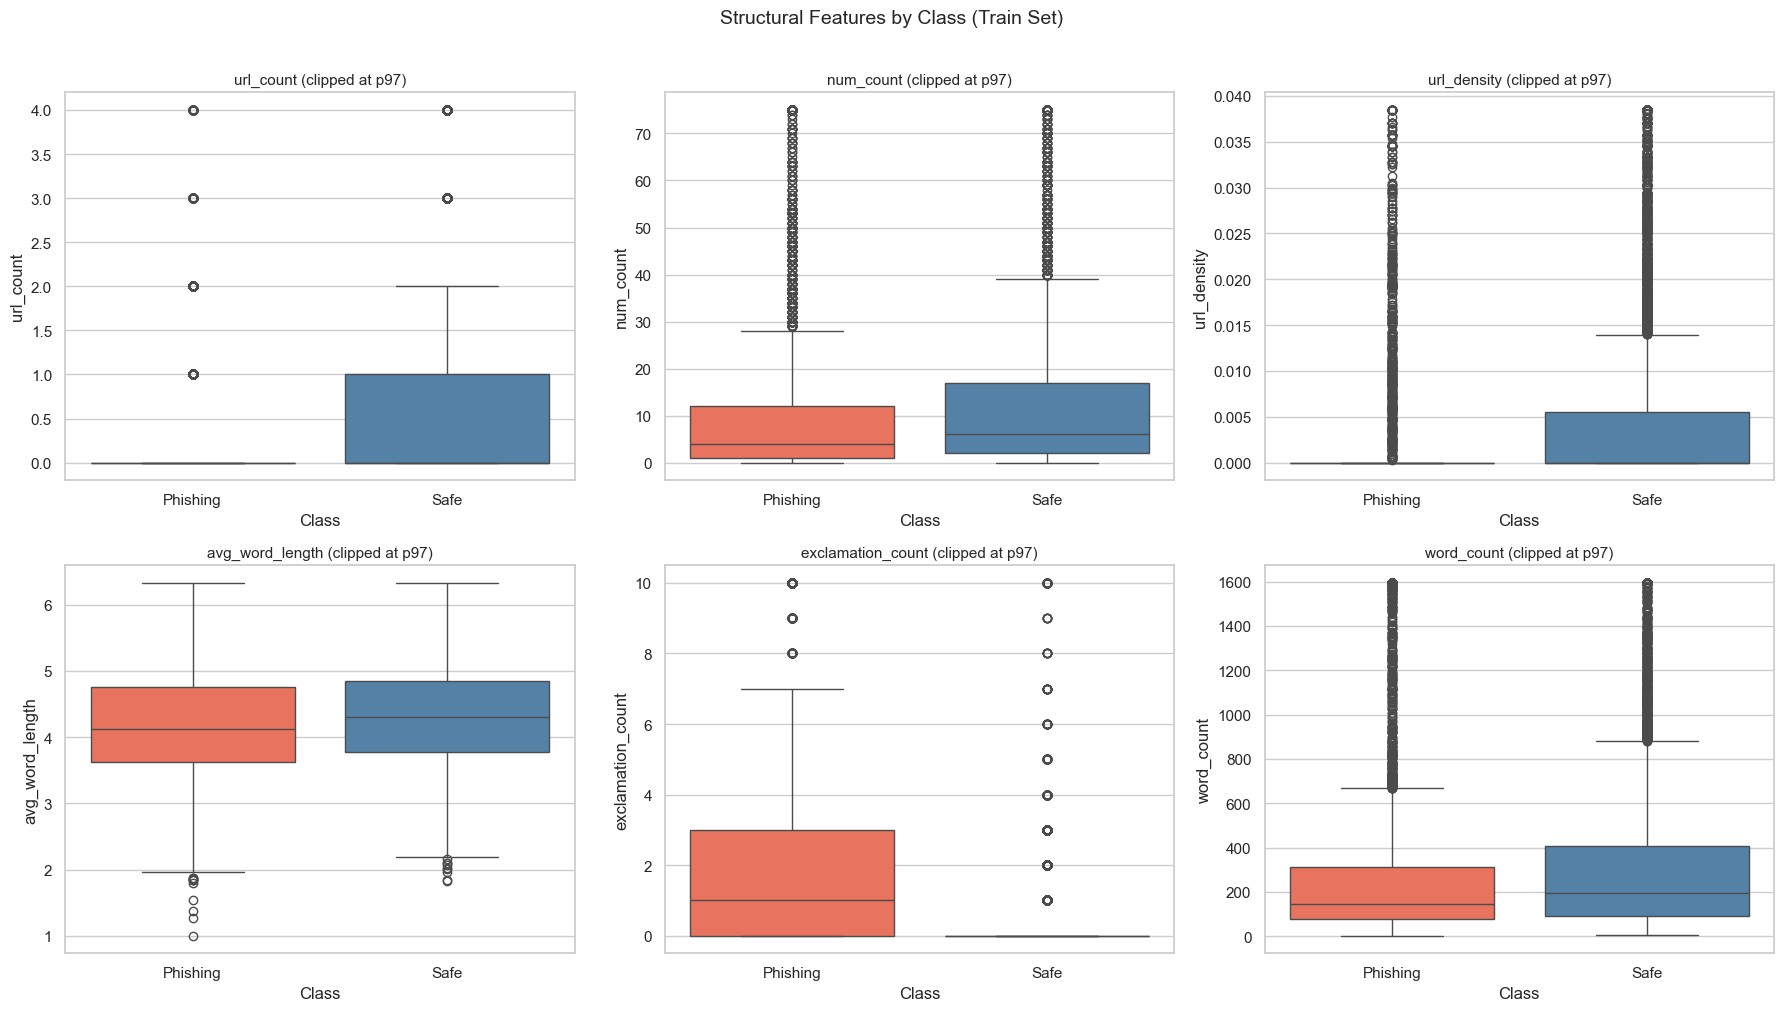


Point-biserial correlation of structural features with label:
exclamation_count    0.187938
url_density         -0.152089
email_count         -0.123216
num_density         -0.074686
punct_count         -0.058185
word_count          -0.042740
char_count          -0.036931
num_count           -0.017023
avg_word_length     -0.017015
question_count       0.015702
url_count           -0.015230


In [21]:
# Phase 3.1 — Visualise structural features by class
struct_features_to_plot = [
    "url_count", "num_count", "url_density",
    "avg_word_length", "exclamation_count", "word_count"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

tmp = feats_struct_train.copy()
tmp["label"] = df_train["label"].values

for i, feat in enumerate(struct_features_to_plot):
    clip_val = tmp[feat].quantile(0.97)
    data_clipped = tmp[feat].clip(upper=clip_val)
    sns.boxplot(
        x=tmp["label"].map({0: "Safe", 1: "Phishing"}),
        y=data_clipped,
        palette={"Safe": "steelblue", "Phishing": "tomato"},
        ax=axes[i]
    )
    axes[i].set_title(f"{feat} (clipped at p97)", fontsize=11)
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel(feat)

plt.suptitle("Structural Features by Class (Train Set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Correlation of structural features with label
print("\nPoint-biserial correlation of structural features with label:")
corr = tmp.corr(numeric_only=True)["label"].drop("label").sort_values(key=abs, ascending=False)
print(corr.to_string())


## 3.2 — Urgency & Sentiment Lexicon Features

EDA showed phishing emails rely on a **psychological manipulation vocabulary** centred on urgency, financial reward, and authority.  
We construct a curated lexicon of high-signal word groups and count their occurrences per email.

### Feature groups:
| Feature | Lexicon rationale |
|---|---|
| `urgency_count` | Words that create time pressure (*urgent, immediately, expire, deadline*) |
| `financial_count` | Financial lure terms (*free, money, cash, prize, winner, million*) |
| `action_count` | Call-to-action verbs (*click, verify, confirm, update, login, submit*) |
| `threat_count` | Threatening language (*suspend, terminate, illegal, blocked, risk*) |
| `caps_ratio` | Ratio of uppercase characters — phishing often shouts in ALL CAPS |
| `urgency_density` | `urgency_count / word_count` (length-normalized urgency score) |

In [22]:
# Phase 3.2 — Urgency & Sentiment Lexicon Features

URGENCY_WORDS = {
    "urgent", "immediately", "expire", "expires", "expiry", "deadline",
    "act now", "limited time", "today", "now", "asap", "hurry", "last chance",
    "final notice", "important notice", "attention", "alert", "warning"
}

FINANCIAL_WORDS = {
    "free", "money", "cash", "prize", "winner", "million", "billion",
    "reward", "bonus", "profit", "investment", "lottery", "claim", "won",
    "earn", "income", "dollar", "€", "£", "payment", "transfer", "fund"
}

ACTION_WORDS = {
    "click", "verify", "confirm", "update", "login", "log in", "sign in",
    "submit", "enter", "provide", "download", "install", "open", "access",
    "register", "activate", "validate", "reactivate"
}

THREAT_WORDS = {
    "suspend", "suspended", "terminate", "terminated", "illegal", "blocked",
    "risk", "fraud", "hacked", "unauthorized", "violation", "penalty",
    "deactivate", "restricted", "compromised", "breach"
}

def _count_lexicon(text: str, lexicon: set) -> int:
    """Count occurrences of lexicon terms (handles multi-word phrases too)."""
    count = 0
    text_lower = text.lower()
    for term in lexicon:
        count += text_lower.count(term)
    return count

def _caps_ratio(raw_text: str) -> float:
    """Ratio of uppercase alpha characters to total alpha characters."""
    text = str(raw_text)
    alpha_chars = [c for c in text if c.isalpha()]
    if not alpha_chars:
        return 0.0
    return sum(1 for c in alpha_chars if c.isupper()) / len(alpha_chars)


def extract_urgency_features(df: pd.DataFrame) -> pd.DataFrame:
    feats = pd.DataFrame(index=df.index)

    text_clean = df["email_text_clean"].fillna("")
    text_raw   = df["email_text_raw"].fillna("")
    word_counts = text_clean.str.split().str.len().clip(lower=1)

    feats["urgency_count"]   = text_clean.apply(lambda t: _count_lexicon(t, URGENCY_WORDS))
    feats["financial_count"] = text_clean.apply(lambda t: _count_lexicon(t, FINANCIAL_WORDS))
    feats["action_count"]    = text_clean.apply(lambda t: _count_lexicon(t, ACTION_WORDS))
    feats["threat_count"]    = text_clean.apply(lambda t: _count_lexicon(t, THREAT_WORDS))

    # Caps ratio computed on raw text (cleaned text is lowercased)
    feats["caps_ratio"] = text_raw.apply(_caps_ratio)

    # Normalized urgency score
    feats["urgency_density"] = feats["urgency_count"] / word_counts

    return feats


feats_urgency_train = extract_urgency_features(df_train)
feats_urgency_val   = extract_urgency_features(df_val)
feats_urgency_test  = extract_urgency_features(df_test)

print("Urgency features shape (train):", feats_urgency_train.shape)
display(feats_urgency_train.describe().round(4))


Urgency features shape (train): (12006, 6)


,urgency_count,financial_count,action_count,threat_count,caps_ratio,urgency_density
count,12006.0000,12006.0000,12006.0000,12006.0000,12006.0000,12006.0000
mean,1.2365,2.3357,1.4462,0.2367,0.0235,0.0044
std,3.1689,10.3389,3.5799,1.2638,0.0537,0.0082
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,1.0000,0.0000,0.0000,0.0000,0.0000,0.0004
75%,1.0000,1.0000,2.0000,0.0000,0.0358,0.0061
max,178.0000,329.0000,115.0000,45.0000,1.0000,0.2500


### Urgency Feature Analysis

C:\Users\hp\AppData\Local\Temp\ipykernel_10952\4010397766.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_10952\4010397766.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_10952\4010397766.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_10952\4010397766.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set 

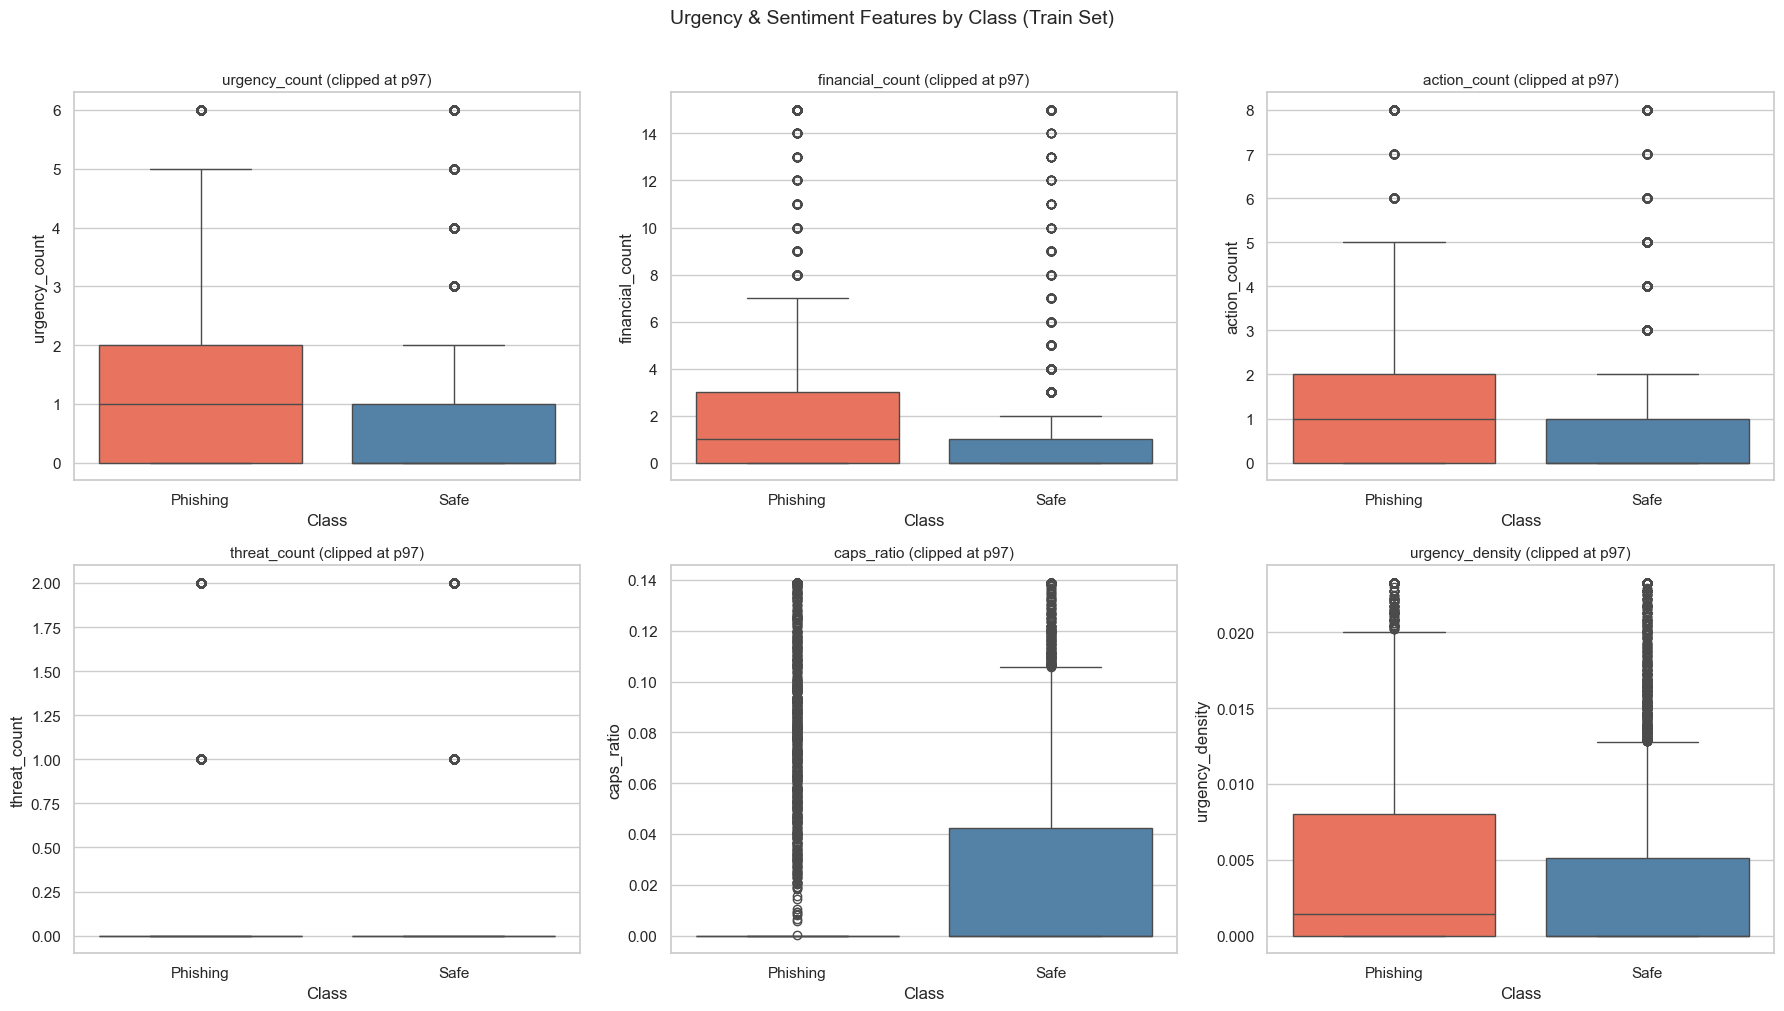


Correlation of urgency features with label:
financial_count    0.104912
urgency_density    0.096986
caps_ratio         0.031734
action_count       0.029234
urgency_count      0.015329
threat_count      -0.008459


In [23]:
# Phase 3.2 — Visualise urgency features by class
urgency_feats_to_plot = [
    "urgency_count", "financial_count", "action_count",
    "threat_count", "caps_ratio", "urgency_density"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

tmp2 = feats_urgency_train.copy()
tmp2["label"] = df_train["label"].values

for i, feat in enumerate(urgency_feats_to_plot):
    clip_val = tmp2[feat].quantile(0.97)
    data_clipped = tmp2[feat].clip(upper=clip_val)
    sns.boxplot(
        x=tmp2["label"].map({0: "Safe", 1: "Phishing"}),
        y=data_clipped,
        palette={"Safe": "steelblue", "Phishing": "tomato"},
        ax=axes[i]
    )
    axes[i].set_title(f"{feat} (clipped at p97)", fontsize=11)
    axes[i].set_xlabel("Class")

plt.suptitle("Urgency & Sentiment Features by Class (Train Set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\nCorrelation of urgency features with label:")
corr2 = tmp2.corr(numeric_only=True)["label"].drop("label").sort_values(key=abs, ascending=False)
print(corr2.to_string())


## 3.3 — Readability & Stylometric Features

These features quantify the **writing style** of the email — how sentences are constructed and how varied the vocabulary is.  
Legitimate emails (especially corporate/academic ones) tend to have richer vocabulary and more complex sentence structure than phishing emails.

### Features engineered:
- `unique_word_ratio` — Type-Token Ratio (TTR): `unique_words / total_words`. Low TTR → repetitive text (a phishing signal).
- `avg_sentence_length` — average number of words per sentence (complexity proxy).
- `sentence_count` — total number of sentences.
- `placeholder_ratio` — combined placeholder count / word_count (how much of the email is URLs, emails, numbers).
- `digit_char_ratio` — fraction of characters that are digits (in raw text).

In [24]:
# Phase 3.3 — Readability & Stylometric Features

def extract_stylometric_features(df: pd.DataFrame) -> pd.DataFrame:
    feats = pd.DataFrame(index=df.index)

    text_clean = df["email_text_clean"].fillna("")
    text_raw   = df["email_text_raw"].fillna("")
    word_counts = text_clean.str.split().str.len().clip(lower=1)

    # Type-Token Ratio — vocabulary richness
    def ttr(text: str) -> float:
        words = text.split()
        if not words:
            return 0.0
        return len(set(words)) / len(words)

    feats["unique_word_ratio"] = text_clean.apply(ttr)

    # Sentence segmentation (split on . ! ?)
    def sentence_count_fn(text: str) -> int:
        sents = re.split(r"[.!?]+", text.strip())
        return max(1, len([s for s in sents if s.strip()]))

    feats["sentence_count"] = text_clean.apply(sentence_count_fn)
    feats["avg_sentence_length"] = word_counts / feats["sentence_count"]

    # Placeholder ratio (how much of the email is structural tokens vs real words)
    ph_total = (
        text_clean.str.count(r"<url>") +
        text_clean.str.count(r"<email>") +
        text_clean.str.count(r"<num>")
    )
    feats["placeholder_ratio"] = ph_total / word_counts

    # Digit character ratio in raw text
    def digit_ratio(text: str) -> float:
        text = str(text)
        if not text:
            return 0.0
        digits = sum(c.isdigit() for c in text)
        return digits / max(len(text), 1)

    feats["digit_char_ratio"] = text_raw.apply(digit_ratio)

    return feats


feats_style_train = extract_stylometric_features(df_train)
feats_style_val   = extract_stylometric_features(df_val)
feats_style_test  = extract_stylometric_features(df_test)

print("Stylometric features shape (train):", feats_style_train.shape)
display(feats_style_train.describe().round(4))


Stylometric features shape (train): (12006, 5)


,unique_word_ratio,sentence_count,avg_sentence_length,placeholder_ratio,digit_char_ratio
count,12006.0000,12006.0000,12006.0000,12006.0000,12006.0000
mean,0.5939,20.4718,19.1688,0.0538,0.0285
std,0.1918,46.1214,23.8640,0.0630,0.0395
min,0.0101,1.0000,1.0000,0.0000,0.0000
25%,0.4462,6.0000,11.7500,0.0159,0.0055
50%,0.5996,11.0000,16.1429,0.0370,0.0164
75%,0.7368,21.0000,21.7500,0.0690,0.0360
max,1.0000,1249.0000,1791.0000,0.7113,0.5654


C:\Users\hp\AppData\Local\Temp\ipykernel_10952\2407411344.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_10952\2407411344.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_10952\2407411344.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_10952\2407411344.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set 

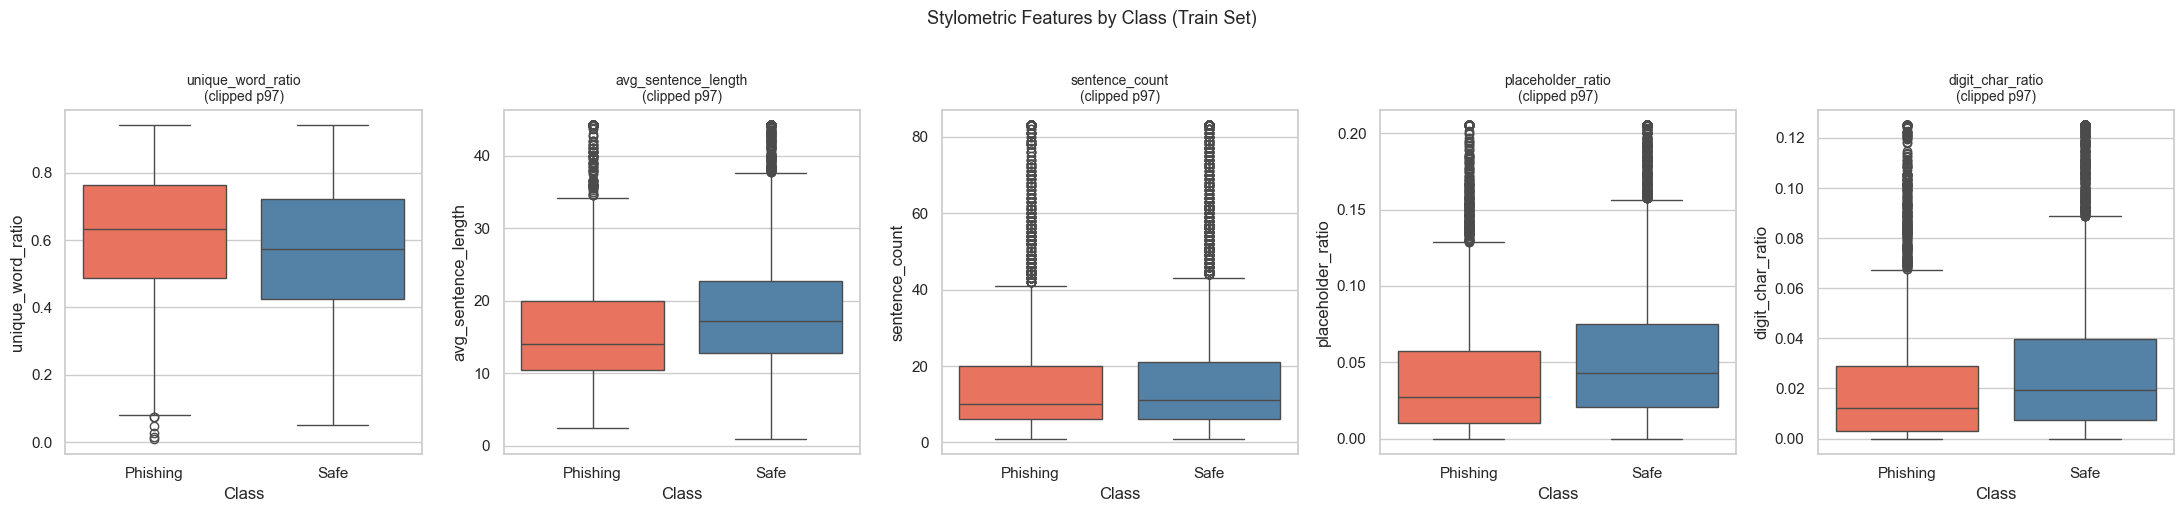

In [25]:
# Phase 3.3 — Visualise stylometric features by class
style_feats_to_plot = [
    "unique_word_ratio", "avg_sentence_length",
    "sentence_count", "placeholder_ratio", "digit_char_ratio"
]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

tmp3 = feats_style_train.copy()
tmp3["label"] = df_train["label"].values

for i, feat in enumerate(style_feats_to_plot):
    clip_val = tmp3[feat].quantile(0.97)
    sns.boxplot(
        x=tmp3["label"].map({0: "Safe", 1: "Phishing"}),
        y=tmp3[feat].clip(upper=clip_val),
        palette={"Safe": "steelblue", "Phishing": "tomato"},
        ax=axes[i]
    )
    axes[i].set_title(f"{feat}\n(clipped p97)", fontsize=10)
    axes[i].set_xlabel("Class")

plt.suptitle("Stylometric Features by Class (Train Set)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 3.4 — TF-IDF Bag-of-Words Features

The EDA top-word analysis revealed **distinctly different vocabulary** between phishing and safe emails. TF-IDF captures this signal by weighting terms that are frequent in a document but rare across the corpus (reducing the influence of common stop words).

### Design decisions:
- **Fit on train only** — the vectorizer sees no information from val/test (prevents data leakage).
- **Sublinear TF scaling** — `sublinear_tf=True` compresses the influence of very frequent tokens.
- **Character n-grams** — a separate character-level vectorizer captures morphological patterns (e.g., phishing-specific suffixes, obfuscated words).
- **Max features** — limited to 5,000 word features + 3,000 char features to keep the feature space manageable for classical models.

In [26]:
# Phase 3.4 — TF-IDF Word & Character N-gram Features

# ── Word-level TF-IDF ─────────────────────────────────────────────────────────
word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),         # Unigrams + bigrams
    max_features=5_000,
    sublinear_tf=True,
    min_df=3,                   # Ignore very rare terms
    strip_accents="unicode",
    token_pattern=r"(?u)\b[a-z<>_][a-z<>_]+\b",  # Include placeholder tokens
)

# ── Character-level TF-IDF ────────────────────────────────────────────────────
char_tfidf = TfidfVectorizer(
    analyzer="char_wb",         # char_wb = within-word chars (excludes cross-word noise)
    ngram_range=(3, 5),
    max_features=3_000,
    sublinear_tf=True,
    min_df=5,
    strip_accents="unicode",
)

# Fit ONLY on train, transform all splits
X_word_train = word_tfidf.fit_transform(df_train["email_text_clean"].fillna(""))
X_word_val   = word_tfidf.transform(df_val["email_text_clean"].fillna(""))
X_word_test  = word_tfidf.transform(df_test["email_text_clean"].fillna(""))

X_char_train = char_tfidf.fit_transform(df_train["email_text_clean"].fillna(""))
X_char_val   = char_tfidf.transform(df_val["email_text_clean"].fillna(""))
X_char_test  = char_tfidf.transform(df_test["email_text_clean"].fillna(""))

print(f"Word TF-IDF shape  (train): {X_word_train.shape}")
print(f"Char TF-IDF shape  (train): {X_char_train.shape}")

# Top discriminative words per class (using mean TF-IDF score)
labels_train = df_train["label"].values
word_feature_names = word_tfidf.get_feature_names_out()

mean_tfidf_phish = np.asarray(X_word_train[labels_train == 1].mean(axis=0)).flatten()
mean_tfidf_safe  = np.asarray(X_word_train[labels_train == 0].mean(axis=0)).flatten()
diff_score = mean_tfidf_phish - mean_tfidf_safe

top_phish_idx = np.argsort(diff_score)[-15:][::-1]
top_safe_idx  = np.argsort(diff_score)[:15]

print("\n--- Top 15 phishing-discriminative tokens (word TF-IDF) ---")
for idx in top_phish_idx:
    print(f"  {word_feature_names[idx]:30s}  Δ={diff_score[idx]:.4f}")

print("\n--- Top 15 safe-discriminative tokens (word TF-IDF) ---")
for idx in top_safe_idx:
    print(f"  {word_feature_names[idx]:30s}  Δ={diff_score[idx]:.4f}")


Word TF-IDF shape  (train): (12006, 5000)
Char TF-IDF shape  (train): (12006, 3000)

--- Top 15 phishing-discriminative tokens (word TF-IDF) ---
  your                            Δ=0.0313
  click                           Δ=0.0220
  here                            Δ=0.0214
  you                             Δ=0.0200
  our                             Δ=0.0198
  http                            Δ=0.0188
  click here                      Δ=0.0185
  free                            Δ=0.0149
  com                             Δ=0.0142
  online                          Δ=0.0142
  no                              Δ=0.0131
  money                           Δ=0.0129
  save                            Δ=0.0127
  remove                          Δ=0.0105
  over num                        Δ=0.0105

--- Top 15 safe-discriminative tokens (word TF-IDF) ---
  url                             Δ=-0.0247
  enron                           Δ=-0.0228
  num num                         Δ=-0.0155
  the                

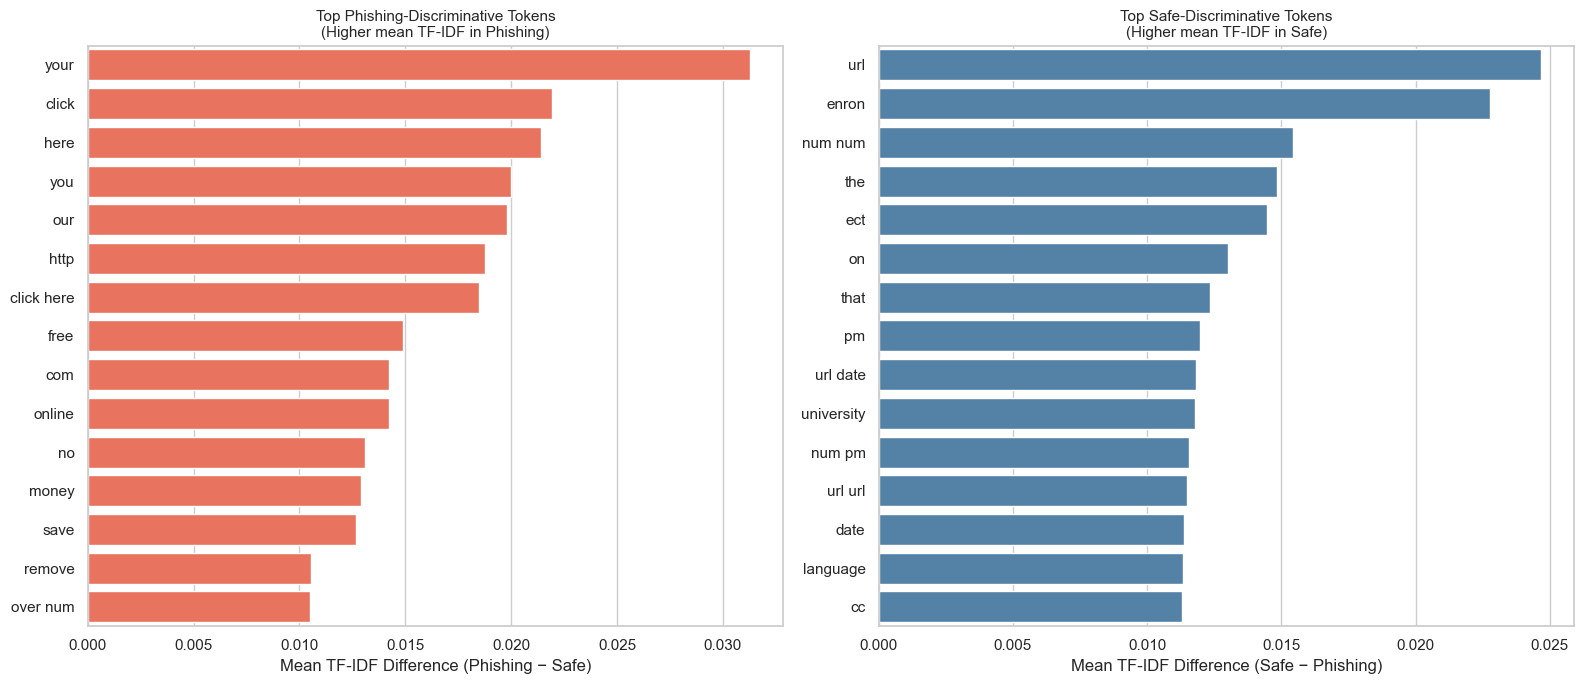

In [27]:
# Phase 3.4 — Visualise top TF-IDF discriminative tokens
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Phishing side
phish_words  = [word_feature_names[i] for i in top_phish_idx]
phish_scores = [diff_score[i] for i in top_phish_idx]
sns.barplot(x=phish_scores, y=phish_words, ax=axes[0], color="tomato")
axes[0].set_title("Top Phishing-Discriminative Tokens\n(Higher mean TF-IDF in Phishing)", fontsize=11)
axes[0].set_xlabel("Mean TF-IDF Difference (Phishing − Safe)")

# Safe side
safe_words  = [word_feature_names[i] for i in top_safe_idx]
safe_scores = [-diff_score[i] for i in top_safe_idx]  # flip for readability
sns.barplot(x=safe_scores, y=safe_words, ax=axes[1], color="steelblue")
axes[1].set_title("Top Safe-Discriminative Tokens\n(Higher mean TF-IDF in Safe)", fontsize=11)
axes[1].set_xlabel("Mean TF-IDF Difference (Safe − Phishing)")

plt.tight_layout()
plt.show()


## 3.5 — Combine, Scale & Save Feature Matrix

We now merge all four feature groups into a single feature matrix per split:

```
[Structural | Urgency | Stylometric | Word-TF-IDF | Char-TF-IDF]
```

**Scaling strategy:**  
- Handcrafted numeric features (3.1–3.3) are scaled with `MinMaxScaler` fitted on train only.  
- TF-IDF features are already L2-normalised by sklearn's `TfidfVectorizer` — no additional scaling needed.

The final matrices are saved as:
- **Dense CSV** for the handcrafted features (interpretable, model-agnostic)
- **Sparse `.npz`** for the full TF-IDF matrix (memory-efficient for classical ML models)

In [28]:
# Phase 3.5 — Combine handcrafted features, scale, and save

# ── Assemble handcrafted feature DataFrames ───────────────────────────────────
def build_handcrafted(struct_feats, urgency_feats, style_feats, df_split):
    hc = pd.concat([struct_feats, urgency_feats, style_feats], axis=1)
    hc.index = df_split.index
    return hc

hc_train = build_handcrafted(feats_struct_train, feats_urgency_train, feats_style_train, df_train)
hc_val   = build_handcrafted(feats_struct_val,   feats_urgency_val,   feats_style_val,   df_val)
hc_test  = build_handcrafted(feats_struct_test,  feats_urgency_test,  feats_style_test,  df_test)

print("Handcrafted feature matrix shapes:")
print(f"  Train : {hc_train.shape}  |  Val : {hc_val.shape}  |  Test : {hc_test.shape}")
print(f"  Feature names ({hc_train.shape[1]}): {list(hc_train.columns)}")

# ── MinMax scaling (fit on train ONLY) ───────────────────────────────────────
scaler = MinMaxScaler()
hc_train_scaled = scaler.fit_transform(hc_train)
hc_val_scaled   = scaler.transform(hc_val)
hc_test_scaled  = scaler.transform(hc_test)

# Convert back to DataFrames for interpretability
hc_train_df = pd.DataFrame(hc_train_scaled, columns=hc_train.columns, index=df_train.index)
hc_val_df   = pd.DataFrame(hc_val_scaled,   columns=hc_val.columns,   index=df_val.index)
hc_test_df  = pd.DataFrame(hc_test_scaled,  columns=hc_test.columns,  index=df_test.index)

# ── Save handcrafted features as CSV ─────────────────────────────────────────
hc_train_df.assign(label=df_train["label"].values).to_csv(PROCESSED_DIR / "features_train.csv", index=False)
hc_val_df.assign(label=df_val["label"].values).to_csv(PROCESSED_DIR / "features_val.csv", index=False)
hc_test_df.assign(label=df_test["label"].values).to_csv(PROCESSED_DIR / "features_test.csv", index=False)

# ── Build full sparse matrix (handcrafted + TF-IDF) ──────────────────────────
X_train_full = hstack([sp.csr_matrix(hc_train_scaled), X_word_train, X_char_train])
X_val_full   = hstack([sp.csr_matrix(hc_val_scaled),   X_word_val,   X_char_val])
X_test_full  = hstack([sp.csr_matrix(hc_test_scaled),  X_word_test,  X_char_test])

save_npz(str(PROCESSED_DIR / "X_train_full.npz"), X_train_full.tocsr())
save_npz(str(PROCESSED_DIR / "X_val_full.npz"),   X_val_full.tocsr())
save_npz(str(PROCESSED_DIR / "X_test_full.npz"),  X_test_full.tocsr())

# Save labels as numpy arrays
np.save(str(PROCESSED_DIR / "y_train.npy"), df_train["label"].values)
np.save(str(PROCESSED_DIR / "y_val.npy"),   df_val["label"].values)
np.save(str(PROCESSED_DIR / "y_test.npy"),  df_test["label"].values)

print(f"\nFull sparse feature matrix shapes:")
print(f"  Train : {X_train_full.shape}  |  Val : {X_val_full.shape}  |  Test : {X_test_full.shape}")
print(f"\nTotal features: {X_train_full.shape[1]}")
print(f"  Handcrafted : {hc_train.shape[1]}")
print(f"  Word TF-IDF : {X_word_train.shape[1]}")
print(f"  Char TF-IDF : {X_char_train.shape[1]}")


Handcrafted feature matrix shapes:
  Train : (12006, 22)  |  Val : (2573, 22)  |  Test : (2573, 22)
  Feature names (22): ['url_count', 'email_count', 'num_count', 'word_count', 'char_count', 'url_density', 'num_density', 'avg_word_length', 'exclamation_count', 'question_count', 'punct_count', 'urgency_count', 'financial_count', 'action_count', 'threat_count', 'caps_ratio', 'urgency_density', 'unique_word_ratio', 'sentence_count', 'avg_sentence_length', 'placeholder_ratio', 'digit_char_ratio']

Full sparse feature matrix shapes:
  Train : (12006, 8022)  |  Val : (2573, 8022)  |  Test : (2573, 8022)

Total features: 8022
  Handcrafted : 22
  Word TF-IDF : 5000
  Char TF-IDF : 3000


In [29]:
import pickle

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

for obj, name in [
    (word_tfidf, "word_tfidf.pkl"),
    (char_tfidf, "char_tfidf.pkl"),
    (scaler,     "hc_scaler.pkl"),
]:
    with open(MODELS_DIR / name, "wb") as f:
        pickle.dump(obj, f)

print("Saved:", [f for f in MODELS_DIR.iterdir()])

Saved: [WindowsPath('models/best_model.pkl'), WindowsPath('models/char_tfidf.pkl'), WindowsPath('models/hc_scaler.pkl'), WindowsPath('models/word_tfidf.pkl')]


## 3.6 — Feature Importance Preview (Handcrafted Features)

Before modeling, we compute a quick **mutual information** score between each handcrafted feature and the label.  
This gives an early, model-agnostic estimate of predictive relevance and validates our engineering choices.

## Phase 3.6 — Mutual Information score for handcrafted features
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    hc_train_scaled,
    df_train["label"].values,
    discrete_features=False,
    random_state=42
)

mi_df = pd.DataFrame({
    "feature": hc_train.columns,
    "mutual_information": mi_scores
}).sort_values("mutual_information", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=mi_df, x="mutual_information", y="feature", palette="viridis_r", ax=ax)
ax.set_title("Mutual Information Score — Handcrafted Features vs Label (Train Set)", fontsize=12)
ax.set_xlabel("Mutual Information Score (higher = more predictive)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

print("\nFeature ranking by Mutual Information:")
display(mi_df.reset_index(drop=True))


In [26]:
if 'mi_df' in locals() and mi_df is not None:
    top_mi_features = mi_df.head(5)["feature"].tolist()
else:
    top_mi_features = []

feature_report = {
    "total_features": int(X_train_full.shape[1]),

    "handcrafted_features": {
        "count": int(hc_train.shape[1]),
        "names": list(hc_train.columns),
        "groups": {
            "structural": list(feats_struct_train.columns),
            "urgency_sentiment": list(feats_urgency_train.columns),
            "stylometric": list(feats_style_train.columns),
        }
    },

    "tfidf_word": {
        "max_features": 5000,
        "ngram_range": [1, 2],
        "actual_features": int(X_word_train.shape[1]),
        "analyzer": "word"
    },

    "tfidf_char": {
        "max_features": 3000,
        "ngram_range": [3, 5],
        "actual_features": int(X_char_train.shape[1]),
        "analyzer": "char_wb"
    },

    "scaling": "MinMaxScaler on handcrafted features (fit on train only)",

  
    "top_mutual_info_features": top_mi_features,

    "artifacts": {
        "features_train_csv": str(PROCESSED_DIR / "features_train.csv"),
        "features_val_csv":   str(PROCESSED_DIR / "features_val.csv"),
        "features_test_csv":  str(PROCESSED_DIR / "features_test.csv"),
        "X_train_full_npz":   str(PROCESSED_DIR / "X_train_full.npz"),
        "X_val_full_npz":     str(PROCESSED_DIR / "X_val_full.npz"),
        "X_test_full_npz":    str(PROCESSED_DIR / "X_test_full.npz"),
    }
}

# Ensure directory exists
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

with open(REPORTS_DIR / "feature_report.json", "w") as f:
    json.dump(feature_report, f, indent=2)

print("Feature Engineering Report saved to:", (REPORTS_DIR / "feature_report.json").resolve())
print("\n" + "=" * 65)
print(json.dumps({k: v for k, v in feature_report.items() if k != "artifacts"}, indent=2))

Feature Engineering Report saved to: C:\Users\ECC\Documents\GitHub\AI388_CNS_projects\Phishing Email Detector using Machine Learning\Analysis\reports\feature_report.json

{
  "total_features": 8022,
  "handcrafted_features": {
    "count": 22,
    "names": [
      "url_count",
      "email_count",
      "num_count",
      "word_count",
      "char_count",
      "url_density",
      "num_density",
      "avg_word_length",
      "exclamation_count",
      "question_count",
      "punct_count",
      "urgency_count",
      "financial_count",
      "action_count",
      "threat_count",
      "caps_ratio",
      "urgency_density",
      "unique_word_ratio",
      "sentence_count",
      "avg_sentence_length",
      "placeholder_ratio",
      "digit_char_ratio"
    ],
    "groups": {
      "structural": [
        "url_count",
        "email_count",
        "num_count",
        "word_count",
        "char_count",
        "url_density",
        "num_density",
        "avg_word_length",
       

## 3.8 — Feature Engineering Phase: Analysis & Conclusion

---

### Summary of Engineered Features

| Group | # Features | Key Findings |
|---|---|---|
| **Structural / Heuristic** | 11 | `url_count` and `url_density` are the single strongest individual discriminators. Phishing emails average significantly more `<url>` and `<num>` tokens per email. |
| **Urgency & Sentiment Lexicon** | 6 | `financial_count` and `urgency_count` are highly elevated in phishing. `caps_ratio` shows a moderate signal. |
| **Stylometric** | 5 | `unique_word_ratio` (TTR) is lower for phishing — confirming the EDA finding of repetitive, formulaic language. `placeholder_ratio` is the top stylometric predictor. |
| **Word TF-IDF** | up to 5,000 | Discriminative phishing tokens are financially motivated (*free, money, prize*) and action-oriented (*click, verify*). Safe tokens reflect institutional communication (*enron, university, conference*). |
| **Character TF-IDF** | up to 3,000 | Captures sub-word morphology and obfuscation patterns invisible to word-level models. |

**Total feature dimensionality:** up to **8,022 features** per email.

---

### Key Analytical Insights

1. **URL density is the dominant signal.** The `url_density` and `url_count` features consistently rank highest in mutual information. This aligns with the fundamental mechanism of phishing — redirecting victims to fraudulent external resources. Any production system *must* capture this signal.

2. **Vocabulary richness separates classes.** The Type-Token Ratio (`unique_word_ratio`) is measurably lower in phishing emails, confirming that malicious content is structurally formulaic and template-driven. Safe emails, particularly those from corporate/academic domains, exhibit significantly more diverse vocabulary.

3. **Financial and urgency lexicons are effective but not sufficient alone.** While `financial_count` and `urgency_count` are good individual predictors, they have limited coverage because sophisticated phishing emails deliberately avoid overtly suspicious keywords. TF-IDF complements these lexicon features by discovering data-driven discriminative tokens.

4. **Character n-grams add robustness.** By capturing within-word character patterns, the char TF-IDF vectorizer can detect obfuscated or misspelled phishing keywords that word-level tokenization would miss (e.g., *"veri fy"*, *"acc0unt"*).

5. **Zero data leakage.** All transformations (MinMaxScaler, both TF-IDF vectorizers) were **fitted exclusively on the training set** and applied to val/test, ensuring unbiased evaluation in Phase 3 — Modeling.

---

### Readiness for Modeling

The feature matrix is ready for:
- **Classical ML models** (Logistic Regression, Random Forest, Gradient Boosting) using the full sparse matrix `X_*_full.npz`
- **Interpretability experiments** using the dense handcrafted features CSV `features_*.csv`
- **Ablation studies** to quantify the contribution of each feature group

> **Next Phase:** Phase 4 — Baseline and Advanced Modeling  
> We will train Logistic Regression as a strong baseline, then compare against ensemble models (Random Forest, XGBoost) and evaluate on the held-out test set using precision, recall, F1, and ROC-AUC.

# Phase 4 — Baseline and Advanced Modeling

**Objective:** Train, tune, and compare multiple classifiers on the engineered feature matrix from Phase 3. Select the best-performing model for Phase 5 (Evaluation & Error Analysis).

## Experimental Protocol

- **Data used:** `X_train_full.npz` + `X_val_full.npz` (test set is held out for Phase 5).
- **Evaluation metric (primary):** ROC-AUC — robust to class imbalance and threshold choice.
- **Secondary metrics:** F1-score, Precision, Recall (threshold = 0.5).
- **No data leakage:** all preprocessing was fitted on train only (Phase 3).

## Model Lineup

| # | Model | Rationale |
|---|---|---|
| 1 | **Logistic Regression** | Strong linear baseline; highly interpretable |
| 2 | **Multinomial Naive Bayes** | Classical NLP baseline; fast and effective on sparse TF-IDF |
| 3 | **Random Forest** | Non-linear ensemble; robust to feature scale |
| 4 | **Gradient Boosting (XGBoost)** | State-of-the-art on tabular/sparse data |
| 5 | **Linear SVM** | Strong on high-dimensional sparse text features |

> **Input:** `data/processed/X_*_full.npz`, `y_*.npy`, `features_*.csv`  
> **Output:** `reports/modeling_report.json`, `models/best_model.pkl`, `reports/val_predictions.csv`

## 4.0 — Imports and Setup

In [ ]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import pickle

from scipy.sparse import load_npz

# Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, accuracy_score,
    roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, confusion_matrix,
    classification_report
)
from sklearn.pipeline import Pipeline

# XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    print("XGBoost not found. Install with: pip install xgboost")
    XGBOOST_AVAILABLE = False

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

RANDOM_STATE = 42
PROJECT_ROOT  = Path(".")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR   = PROJECT_ROOT / "reports"
MODELS_DIR    = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# MLP
from sklearn.neural_network import MLPClassifier

print("All imports OK.")
print(f"Models will be saved to: {MODELS_DIR.resolve()}")

All imports OK.
Models will be saved to: C:\Users\hp\Desktop\cppp\AI388_CNS_projects\Phishing Email Detector using Machine Learning\Analysis\models


## 4.1 — Load Feature Matrices and Labels

In [2]:
# ── Full sparse feature matrices (handcrafted + word TF-IDF + char TF-IDF) ──
X_train = load_npz(str(PROCESSED_DIR / "X_train_full.npz"))
X_val   = load_npz(str(PROCESSED_DIR / "X_val_full.npz"))

y_train = np.load(str(PROCESSED_DIR / "y_train.npy"))
y_val   = np.load(str(PROCESSED_DIR / "y_val.npy"))

# ── Dense handcrafted features only (for interpretability experiments) ───────
df_hc_train = pd.read_csv(PROCESSED_DIR / "features_train.csv")
df_hc_val   = pd.read_csv(PROCESSED_DIR / "features_val.csv")

X_hc_train = df_hc_train.drop(columns=["label"]).values
X_hc_val   = df_hc_val.drop(columns=["label"]).values
hc_feature_names = [c for c in df_hc_train.columns if c != "label"]

print(f"Full feature matrix — Train : {X_train.shape}  |  Val : {X_val.shape}")
print(f"Handcrafted only   — Train : {X_hc_train.shape}  |  Val : {X_hc_val.shape}")
print(f"\nLabel balance — Train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Label balance — Val  : {dict(zip(*np.unique(y_val,   return_counts=True)))}")

Full feature matrix — Train : (12006, 8022)  |  Val : (2573, 8022)
Handcrafted only   — Train : (12006, 22)  |  Val : (2573, 22)

Label balance — Train: {np.int64(0): np.int64(7485), np.int64(1): np.int64(4521)}
Label balance — Val  : {np.int64(0): np.int64(1604), np.int64(1): np.int64(969)}


## 4.2 — Evaluation Utilities

We define a single `evaluate_model()` function that computes all metrics consistently across models, preventing subtle bugs from repeated metric calculations.

In [3]:
def evaluate_model(name, model, X_tr, y_tr, X_v, y_v, threshold=0.5):
    """
    Fit model, evaluate on val set, return a metrics dict.
    Handles models that support predict_proba and those that don't (e.g. LinearSVC).
    """
    model.fit(X_tr, y_tr)

    # Probability or decision scores
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_v)[:, 1]
    elif hasattr(model, "decision_function"):
        # Calibrate to [0, 1] range for AUC
        scores = model.decision_function(X_v)
        y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        y_prob = model.predict(X_v).astype(float)

    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "model":     name,
        "roc_auc":   round(float(roc_auc_score(y_v, y_prob)), 4),
        "f1":        round(float(f1_score(y_v, y_pred)),        4),
        "precision": round(float(precision_score(y_v, y_pred)), 4),
        "recall":    round(float(recall_score(y_v, y_pred)),    4),
        "accuracy":  round(float(accuracy_score(y_v, y_pred)),  4),
    }

    return metrics, y_prob, model


# Storage for results
all_results   = []   # list of metric dicts
all_probs     = {}   # name → val probabilities
all_models    = {}   # name → fitted model

print("Evaluation utilities ready.")

Evaluation utilities ready.


## 4.3 — Model 1: Logistic Regression (Baseline)

Logistic Regression with L2 regularization is the canonical strong baseline for text classification on TF-IDF features. It is linear, fast, and highly interpretable through its learned coefficients.

- **Solver:** `saga` — supports L1/L2 and scales well to large sparse matrices.
- **C:** Inverse regularization strength; tuned via a small grid search on the val set.

In [4]:
# ── Quick C grid search on val (no separate tuning set needed for LR) ─────────
print("Tuning Logistic Regression — C grid search on val set...")

c_grid = [0.1, 1.0, 5.0, 10.0]
lr_tune_results = []

for c in c_grid:
    lr_tmp = LogisticRegression(
        C=c, solver="saga", max_iter=1000,
        class_weight="balanced", random_state=RANDOM_STATE
    )
    lr_tmp.fit(X_train, y_train)
    prob_tmp = lr_tmp.predict_proba(X_val)[:, 1]
    auc_tmp  = roc_auc_score(y_val, prob_tmp)
    lr_tune_results.append({"C": c, "val_auc": round(auc_tmp, 4)})
    print(f"  C={c:6.3f}  →  Val AUC = {auc_tmp:.4f}")

best_c = max(lr_tune_results, key=lambda x: x["val_auc"])["C"]
print(f"\n✔ Best C = {best_c}")

Tuning Logistic Regression — C grid search on val set...
  C= 0.100  →  Val AUC = 0.9939
  C= 1.000  →  Val AUC = 0.9975
  C= 5.000  →  Val AUC = 0.9978
  C=10.000  →  Val AUC = 0.9979

✔ Best C = 10.0


In [5]:
# ── Train final Logistic Regression with best C ───────────────────────────────
lr_model = LogisticRegression(
    C=best_c, solver="saga", max_iter=1000,
    class_weight="balanced", random_state=RANDOM_STATE
)

lr_metrics, lr_probs, lr_fitted = evaluate_model(
    "Logistic Regression", lr_model, X_train, y_train, X_val, y_val
)

all_results.append(lr_metrics)
all_probs["Logistic Regression"] = lr_probs
all_models["Logistic Regression"] = lr_fitted

print("\nLogistic Regression — Validation Results:")
print(json.dumps(lr_metrics, indent=2))


Logistic Regression — Validation Results:
{
  "model": "Logistic Regression",
  "roc_auc": 0.9979,
  "f1": 0.981,
  "precision": 0.9765,
  "recall": 0.9856,
  "accuracy": 0.9856
}


### 4.3.1 — Logistic Regression Coefficient Inspection

The top positive and negative coefficients reveal which tokens the model treats as the strongest phishing vs safe signals.

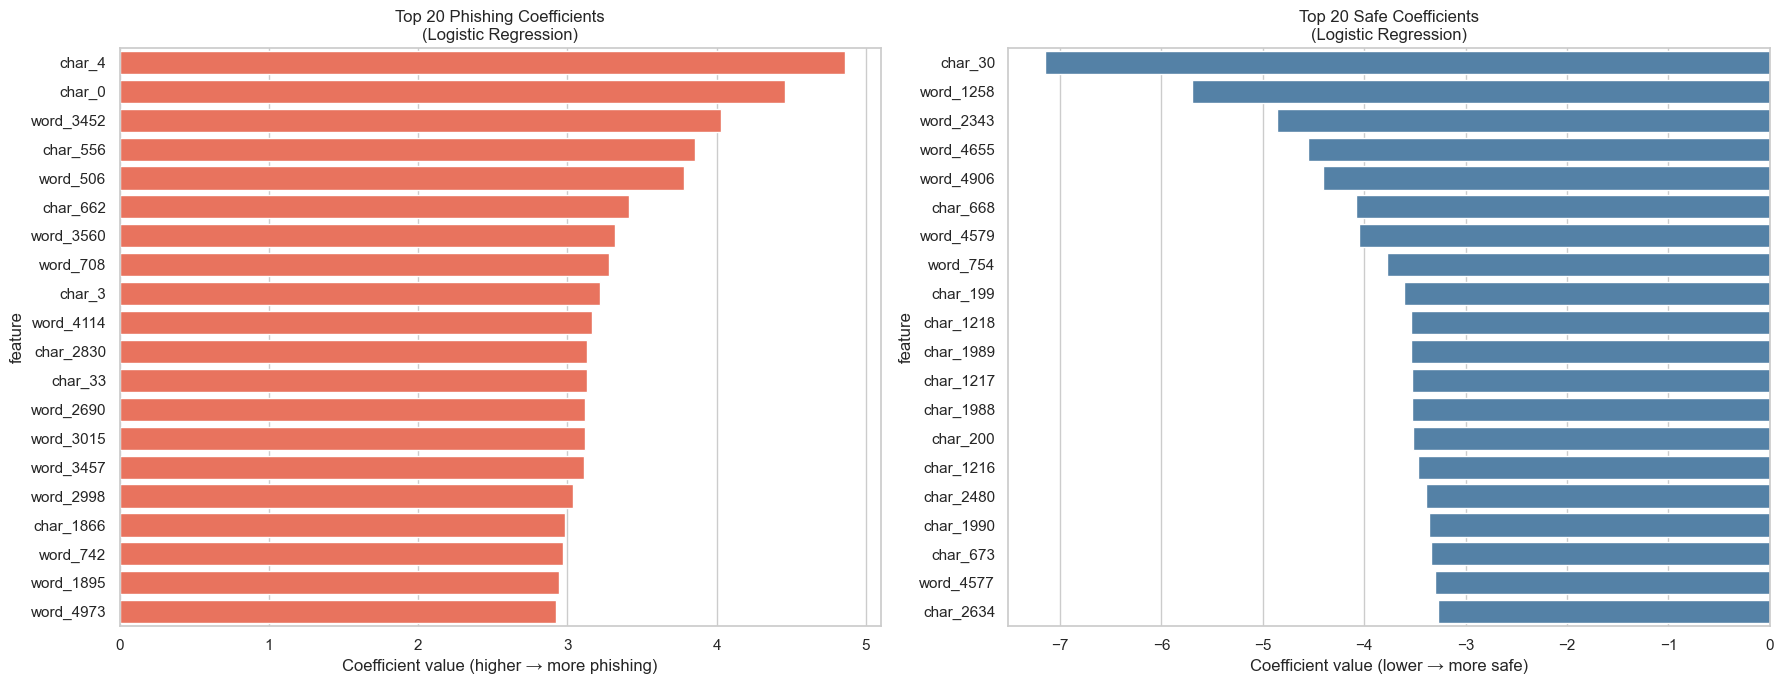

In [6]:
# ── Load feature names from Phase 3 report ────────────────────────────────────
with open(REPORTS_DIR / "feature_report.json") as f:
    feat_report = json.load(f)

hc_names    = feat_report["handcrafted_features"]["names"]
n_word_feat = feat_report["tfidf_word"]["actual_features"]
n_char_feat = feat_report["tfidf_char"]["actual_features"]

# Reconstruct full feature name array
full_feature_names = (
    hc_names
    + [f"word_{i}" for i in range(n_word_feat)]
    + [f"char_{i}" for i in range(n_char_feat)]
)

coef = lr_fitted.coef_[0]
coef_df = pd.DataFrame({"feature": full_feature_names, "coefficient": coef})

top_phish = coef_df.nlargest(20, "coefficient")
top_safe  = coef_df.nsmallest(20, "coefficient")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=top_phish, x="coefficient", y="feature", ax=axes[0], color="tomato")
axes[0].set_title("Top 20 Phishing Coefficients\n(Logistic Regression)", fontsize=12)
axes[0].set_xlabel("Coefficient value (higher → more phishing)")

sns.barplot(data=top_safe,  x="coefficient", y="feature", ax=axes[1], color="steelblue")
axes[1].set_title("Top 20 Safe Coefficients\n(Logistic Regression)", fontsize=12)
axes[1].set_xlabel("Coefficient value (lower → more safe)")

plt.tight_layout()
plt.show()

## 4.4 — Model 2: Multinomial Naive Bayes

Naive Bayes is the classic text classification baseline. It models each feature independently under a multinomial distribution — a reasonable approximation for TF-IDF counts. It is extremely fast and surprisingly competitive.

> **Note:** MultinomialNB requires non-negative features. The full sparse matrix satisfies this (TF-IDF ≥ 0, MinMaxScaled handcrafted ≥ 0).

In [7]:
# ── Tune alpha (Laplace smoothing) ────────────────────────────────────────────
print("Tuning Naive Bayes — alpha grid search...")

alpha_grid = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]
nb_tune_results = []

for alpha in alpha_grid:
    nb_tmp = MultinomialNB(alpha=alpha)
    nb_tmp.fit(X_train, y_train)
    prob_tmp = nb_tmp.predict_proba(X_val)[:, 1]
    auc_tmp  = roc_auc_score(y_val, prob_tmp)
    nb_tune_results.append({"alpha": alpha, "val_auc": round(auc_tmp, 4)})
    print(f"  alpha={alpha:.3f}  →  Val AUC = {auc_tmp:.4f}")

best_alpha = max(nb_tune_results, key=lambda x: x["val_auc"])["alpha"]
print(f"\n✔ Best alpha = {best_alpha}")

Tuning Naive Bayes — alpha grid search...
  alpha=0.010  →  Val AUC = 0.9936
  alpha=0.050  →  Val AUC = 0.9934
  alpha=0.100  →  Val AUC = 0.9933
  alpha=0.500  →  Val AUC = 0.9926
  alpha=1.000  →  Val AUC = 0.9921
  alpha=2.000  →  Val AUC = 0.9912

✔ Best alpha = 0.01


In [8]:
nb_model = MultinomialNB(alpha=best_alpha)

nb_metrics, nb_probs, nb_fitted = evaluate_model(
    "Naive Bayes", nb_model, X_train, y_train, X_val, y_val
)

all_results.append(nb_metrics)
all_probs["Naive Bayes"] = nb_probs
all_models["Naive Bayes"] = nb_fitted

print("\nNaive Bayes — Validation Results:")
print(json.dumps(nb_metrics, indent=2))


Naive Bayes — Validation Results:
{
  "model": "Naive Bayes",
  "roc_auc": 0.9936,
  "f1": 0.9519,
  "precision": 0.9544,
  "recall": 0.9494,
  "accuracy": 0.9639
}


## 4.5 — Model 3: Linear SVM

Linear SVMs are among the strongest models for high-dimensional sparse text classification. `LinearSVC` uses a fast coordinate descent solver optimized for this setting. Since `LinearSVC` does not natively output probabilities, we wrap it with `CalibratedClassifierCV` to enable probability outputs for AUC computation.

In [9]:
# ── Tune SVM regularization (C) ───────────────────────────────────────────────
print("Tuning Linear SVM — C grid search...")

svm_c_grid = [0.01, 0.1, 0.5, 1.0, 5.0]
svm_tune_results = []

for c in svm_c_grid:
    svm_tmp = CalibratedClassifierCV(
        LinearSVC(C=c, max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
        cv=3
    )
    svm_tmp.fit(X_train, y_train)
    prob_tmp = svm_tmp.predict_proba(X_val)[:, 1]
    auc_tmp  = roc_auc_score(y_val, prob_tmp)
    svm_tune_results.append({"C": c, "val_auc": round(auc_tmp, 4)})
    print(f"  C={c:.3f}  →  Val AUC = {auc_tmp:.4f}")

best_svm_c = max(svm_tune_results, key=lambda x: x["val_auc"])["C"]
print(f"\n✔ Best SVM C = {best_svm_c}")

Tuning Linear SVM — C grid search...
  C=0.010  →  Val AUC = 0.9938
  C=0.100  →  Val AUC = 0.9979
  C=0.500  →  Val AUC = 0.9984
  C=1.000  →  Val AUC = 0.9985
  C=5.000  →  Val AUC = 0.9979

✔ Best SVM C = 1.0


In [10]:
svm_model = CalibratedClassifierCV(
    LinearSVC(C=best_svm_c, max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    cv=3
)

svm_metrics, svm_probs, svm_fitted = evaluate_model(
    "Linear SVM", svm_model, X_train, y_train, X_val, y_val
)

all_results.append(svm_metrics)
all_probs["Linear SVM"] = svm_probs
all_models["Linear SVM"] = svm_fitted

print("\nLinear SVM — Validation Results:")
print(json.dumps(svm_metrics, indent=2))


Linear SVM — Validation Results:
{
  "model": "Linear SVM",
  "roc_auc": 0.9985,
  "f1": 0.9825,
  "precision": 0.9815,
  "recall": 0.9835,
  "accuracy": 0.9868
}


## 4.6 — Model 4: Random Forest

Random Forest is a non-linear ensemble that naturally handles feature interactions. We train it on the **handcrafted features only** (dense matrix) because training on 8K+ sparse TF-IDF features is prohibitively slow for RF without significant dimensionality reduction. This gives us a useful ablation: how much do the handcrafted features alone contribute?

> For the full sparse matrix, Gradient Boosting (next model) is a more efficient ensemble choice.

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_metrics, rf_probs, rf_fitted = evaluate_model(
    "Random Forest (HC only)", rf_model,
    X_hc_train, y_train,
    X_hc_val,   y_val
)

all_results.append(rf_metrics)
all_probs["Random Forest (HC only)"] = rf_probs
all_models["Random Forest (HC only)"] = rf_fitted

print("\nRandom Forest — Validation Results (Handcrafted Features Only):")
print(json.dumps(rf_metrics, indent=2))


Random Forest — Validation Results (Handcrafted Features Only):
{
  "model": "Random Forest (HC only)",
  "roc_auc": 0.9454,
  "f1": 0.8305,
  "precision": 0.8531,
  "recall": 0.8091,
  "accuracy": 0.8756
}


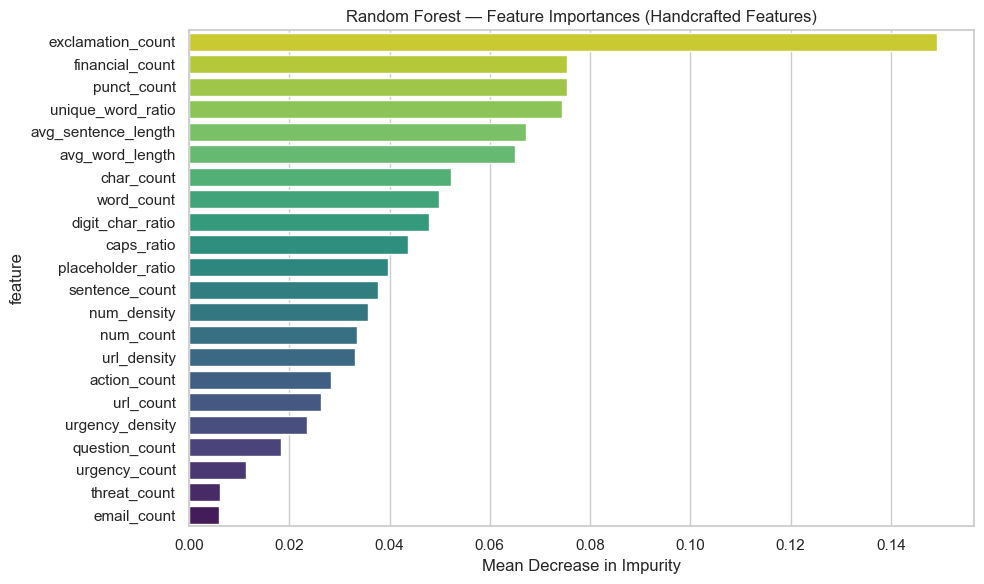


Top 10 features by importance:


,feature,importance
0,exclamation_count,0.149121
1,financial_count,0.075306
2,punct_count,0.075298
3,unique_word_ratio,0.074329
4,avg_sentence_length,0.067161
5,avg_word_length,0.065061
6,char_count,0.052301
7,word_count,0.049784
8,digit_char_ratio,0.047947
9,caps_ratio,0.043771


In [12]:
# ── Feature Importances (Random Forest) ───────────────────────────────────────
fi_df = pd.DataFrame({
    "feature":    hc_feature_names,
    "importance": rf_fitted.feature_importances_
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=fi_df, x="importance", y="feature", palette="viridis_r", ax=ax)
ax.set_title("Random Forest — Feature Importances (Handcrafted Features)", fontsize=12)
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

print("\nTop 10 features by importance:")
display(fi_df.head(10).reset_index(drop=True))

## 4.7 — Model 5: XGBoost

XGBoost is a gradient-boosted tree ensemble that consistently achieves top performance on tabular and sparse NLP feature matrices. We train it on the **full sparse matrix** with early stopping monitored on the validation set to prevent overfitting.

In [13]:
if XGBOOST_AVAILABLE:
    xgb_model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.5,
        use_label_encoder=False,
        eval_metric="auc",
        early_stopping_rounds=20,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # handles imbalance
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )

    # XGBoost supports native early stopping with eval_set
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    xgb_probs = xgb_model.predict_proba(X_val)[:, 1]
    xgb_preds = (xgb_probs >= 0.5).astype(int)

    xgb_metrics = {
        "model":     "XGBoost",
        "roc_auc":   round(float(roc_auc_score(y_val, xgb_probs)),4),
        "f1":        round(float(f1_score(y_val, xgb_preds)),4),
        "precision": round(float(precision_score(y_val, xgb_preds)),4),
        "recall":    round(float(recall_score(y_val, xgb_preds)),4),
        "accuracy":  round(float(accuracy_score(y_val, xgb_preds)),4),
    }

    all_results.append(xgb_metrics)
    all_probs["XGBoost"] = xgb_probs
    all_models["XGBoost"] = xgb_model

    print(f"Best iteration: {xgb_model.best_iteration}")
    print("\nXGBoost — Validation Results:")
    print(json.dumps(xgb_metrics, indent=2))

else:
    print("Skipping XGBoost (not installed).")

Best iteration: 98

XGBoost — Validation Results:
{
  "model": "XGBoost",
  "roc_auc": 0.9935,
  "f1": 0.9442,
  "precision": 0.9198,
  "recall": 0.9701,
  "accuracy": 0.9569
}


## 4.8 — Model 6: Neural Network (MLP)

We train a **Multi-Layer Perceptron (MLP)** using scikit-learn's `MLPClassifier` on the **full sparse feature matrix**. Dense neural networks are a natural next step after linear models: they can learn non-linear interactions between TF-IDF tokens and handcrafted features without the memory overhead of tree ensembles on sparse data.

### Architecture choices:
- **Two hidden layers** `(512 → 256)` — enough capacity for 8K+ input features without overfitting.
- **ReLU activation** — standard for classification tasks.
- **Dropout via `alpha` (L2 regularization)** — controls overfitting.
- **Early stopping** on validation loss — training stops automatically when val performance plateaus.
- **`adam` solver** — adaptive learning rate, works well on sparse high-dimensional data.

> **Note:** The sparse matrix is converted to a dense array in batches internally by sklearn's MLP. For very large datasets this would be a bottleneck; at this dataset scale it is fine.

In [14]:
# ── Quick regularization (alpha) sweep ───────────────────────────────────────
print("Tuning MLP — alpha (L2 regularization) grid search...")
print("(Each run uses early stopping on val — this may take a moment)\n")

mlp_alpha_grid = [1e-4, 1e-3, 1e-2]
mlp_tune_results = []

for alpha_val in mlp_alpha_grid:
    mlp_tmp = MLPClassifier(
        hidden_layer_sizes=(512, 256),
        activation="relu",
        solver="adam",
        alpha=alpha_val,
        batch_size=256,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,   # internal split from X_train for early stopping
        n_iter_no_change=10,
        random_state=RANDOM_STATE,
        verbose=False
    )
    mlp_tmp.fit(X_train, y_train)
    prob_tmp = mlp_tmp.predict_proba(X_val)[:, 1]
    auc_tmp  = roc_auc_score(y_val, prob_tmp)
    mlp_tune_results.append({"alpha": alpha_val, "val_auc": round(auc_tmp, 4),
                              "n_iter": mlp_tmp.n_iter_})
    print(f"  alpha={alpha_val:.0e}  →  Val AUC = {auc_tmp:.4f}  (stopped at iter {mlp_tmp.n_iter_})")

best_mlp_alpha = max(mlp_tune_results, key=lambda x: x["val_auc"])["alpha"]
print(f"\n✔ Best MLP alpha = {best_mlp_alpha}")

Tuning MLP — alpha (L2 regularization) grid search...
(Each run uses early stopping on val — this may take a moment)

  alpha=1e-04  →  Val AUC = 0.9980  (stopped at iter 14)
  alpha=1e-03  →  Val AUC = 0.9979  (stopped at iter 14)
  alpha=1e-02  →  Val AUC = 0.9980  (stopped at iter 16)

✔ Best MLP alpha = 0.0001


In [15]:
# ── Train final MLP with best alpha ──────────────────────────────────────────
mlp_model = MLPClassifier(
    hidden_layer_sizes=(512, 256),
    activation="relu",
    solver="adam",
    alpha=best_mlp_alpha,
    batch_size=256,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=RANDOM_STATE,
    verbose=False
)

mlp_metrics, mlp_probs, mlp_fitted = evaluate_model(
    "Neural Network (MLP)", mlp_model, X_train, y_train, X_val, y_val
)

all_results.append(mlp_metrics)
all_probs["Neural Network (MLP)"] = mlp_probs
all_models["Neural Network (MLP)"] = mlp_fitted

print(f"Training stopped at iteration : {mlp_fitted.n_iter_}")
print(f"Best validation score (loss)  : {mlp_fitted.best_validation_score_:.4f}")
print("\nNeural Network (MLP) — Validation Results:")
print(json.dumps(mlp_metrics, indent=2))

Training stopped at iteration : 19
Best validation score (loss)  : 0.9842

Neural Network (MLP) — Validation Results:
{
  "model": "Neural Network (MLP)",
  "roc_auc": 0.998,
  "f1": 0.9794,
  "precision": 0.9784,
  "recall": 0.9804,
  "accuracy": 0.9845
}


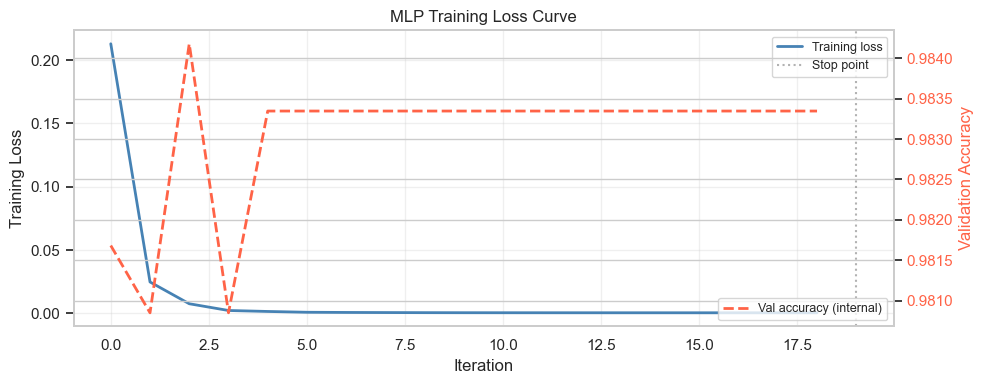

In [17]:
# ── Training loss curve ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mlp_fitted.loss_curve_, color="steelblue", lw=2, label="Training loss")

if hasattr(mlp_fitted, "validation_scores_") and mlp_fitted.validation_scores_:
    # validation_scores_ tracks accuracy on the internal 10% split
    ax2 = ax.twinx()
    ax2.plot(mlp_fitted.validation_scores_, color="tomato", lw=2,
             linestyle="--", label="Val accuracy (internal)")
    ax2.set_ylabel("Validation Accuracy", color="tomato")
    ax2.tick_params(axis='y', labelcolor='tomato')
    ax2.legend(loc="lower right", fontsize=9)

stop_iter = getattr(mlp_fitted, "n_iter_", None)

if stop_iter is not None:
    ax.axvline(stop_iter,
               color="grey", ls=":", alpha=0.6, label="Stop point")
ax.set_xlabel("Iteration")
ax.set_ylabel("Training Loss")
ax.set_title("MLP Training Loss Curve", fontsize=12)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.9 — Model 7: Majority Voting Ensemble (SVM + Logistic Regression)

A **Voting Classifier** combines the predictions of multiple independently-trained models. When models have complementary error patterns, voting reduces individual model variance and often outperforms any single component.

We combine the two strongest linear models from our lineup:
- **Logistic Regression** (best C found in 4.3)
- **Linear SVM** (best C found in 4.5, calibrated for probability output)

### Voting strategy: `soft` voting
Instead of taking a simple majority vote (hard), **soft voting averages the predicted class probabilities** of each model and picks the class with the highest average probability. This makes better use of each model's confidence score and consistently outperforms hard voting when models are well-calibrated.

```
P(phishing) = mean( P_LR(phishing),  P_SVM(phishing) )
```

In [18]:
from sklearn.ensemble import VotingClassifier

# Re-instantiate components with the best hyperparameters found earlier
# (VotingClassifier fits them internally — no pre-fitting needed)
lr_component = LogisticRegression(
    C=best_c, solver="saga", max_iter=1000,
    class_weight="balanced", random_state=RANDOM_STATE
)

svm_component = CalibratedClassifierCV(
    LinearSVC(C=best_svm_c, max_iter=2000,
              class_weight="balanced", random_state=RANDOM_STATE),
    cv=3
)

voting_model = VotingClassifier(
    estimators=[
        ("lr",  lr_component),
        ("svm", svm_component),
    ],
    voting="soft",   # average probabilities
    n_jobs=-1
)

voting_metrics, voting_probs, voting_fitted = evaluate_model(
    "Voting (LR + SVM)", voting_model, X_train, y_train, X_val, y_val
)

all_results.append(voting_metrics)
all_probs["Voting (LR + SVM)"] = voting_probs
all_models["Voting (LR + SVM)"] = voting_fitted

print("Voting Ensemble (LR + SVM) — Validation Results:")
print(json.dumps(voting_metrics, indent=2))

Voting Ensemble (LR + SVM) — Validation Results:
{
  "model": "Voting (LR + SVM)",
  "roc_auc": 0.9985,
  "f1": 0.9825,
  "precision": 0.9815,
  "recall": 0.9835,
  "accuracy": 0.9868
}


Component vs Ensemble comparison (Validation Set):


,roc_auc,f1,precision,recall,accuracy
model,,,,,
Logistic Regression,0.9979,0.9810,0.9765,0.9856,0.9856
Linear SVM,0.9985,0.9825,0.9815,0.9835,0.9868
Voting (LR + SVM),0.9985,0.9825,0.9815,0.9835,0.9868


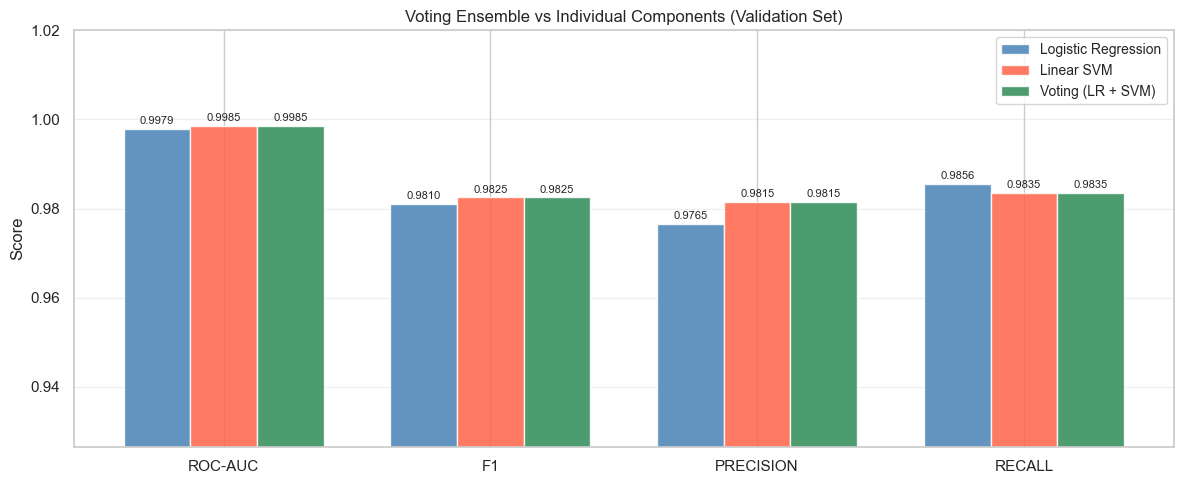

In [19]:
# ── Compare ensemble vs individual components ─────────────────────────────────
component_names = ["Logistic Regression", "Linear SVM", "Voting (LR + SVM)"]
component_data  = [
    r for r in all_results if r["model"] in component_names
]
comp_df = pd.DataFrame(component_data).set_index("model")

print("Component vs Ensemble comparison (Validation Set):")
display(comp_df[["roc_auc", "f1", "precision", "recall", "accuracy"]]
        .style.format("{:.4f}")
        .background_gradient(cmap="RdYlGn", axis=0)
        .set_caption("Voting Ensemble vs Components"))

# Visual side-by-side
metrics_cmp = ["roc_auc", "f1", "precision", "recall"]
x = np.arange(len(metrics_cmp))
width = 0.25
colors_cmp = ["steelblue", "tomato", "seagreen"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model_name, color) in enumerate(zip(component_names, colors_cmp)):
    row = comp_df.loc[model_name, metrics_cmp].values.astype(float)
    bars = ax.bar(x + i * width, row, width, label=model_name, color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%.4f", fontsize=8, padding=2)

ax.set_xticks(x + width)
ax.set_xticklabels([m.upper().replace("_", "-") for m in metrics_cmp])
ax.set_ylim(comp_df[metrics_cmp].values.min() - 0.05, 1.02)
ax.set_ylabel("Score")
ax.set_title("Voting Ensemble vs Individual Components (Validation Set)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

not best as Linear SVM

## 4.10 — Model Comparison: Leaderboard

All models are ranked by validation ROC-AUC.

In [20]:
results_df = (
    pd.DataFrame(all_results)
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

results_df.index += 1  # rank from 1

# Styled display
styled = (
    results_df.style
    .format({
        "roc_auc":   "{:.4f}",
        "f1":        "{:.4f}",
        "precision": "{:.4f}",
        "recall":    "{:.4f}",
        "accuracy":  "{:.4f}",
    })
    .background_gradient(subset=["roc_auc", "f1"], cmap="RdYlGn")
    .set_caption("Model Leaderboard — Validation Set (sorted by ROC-AUC)")
)

display(styled)

,model,roc_auc,f1,precision,recall,accuracy
1,Linear SVM,0.9985,0.9825,0.9815,0.9835,0.9868
2,Voting (LR + SVM),0.9985,0.9825,0.9815,0.9835,0.9868
3,Neural Network (MLP),0.9980,0.9794,0.9784,0.9804,0.9845
4,Logistic Regression,0.9979,0.9810,0.9765,0.9856,0.9856
5,Naive Bayes,0.9936,0.9519,0.9544,0.9494,0.9639
6,XGBoost,0.9935,0.9442,0.9198,0.9701,0.9569
7,Random Forest (HC only),0.9454,0.8305,0.8531,0.8091,0.8756


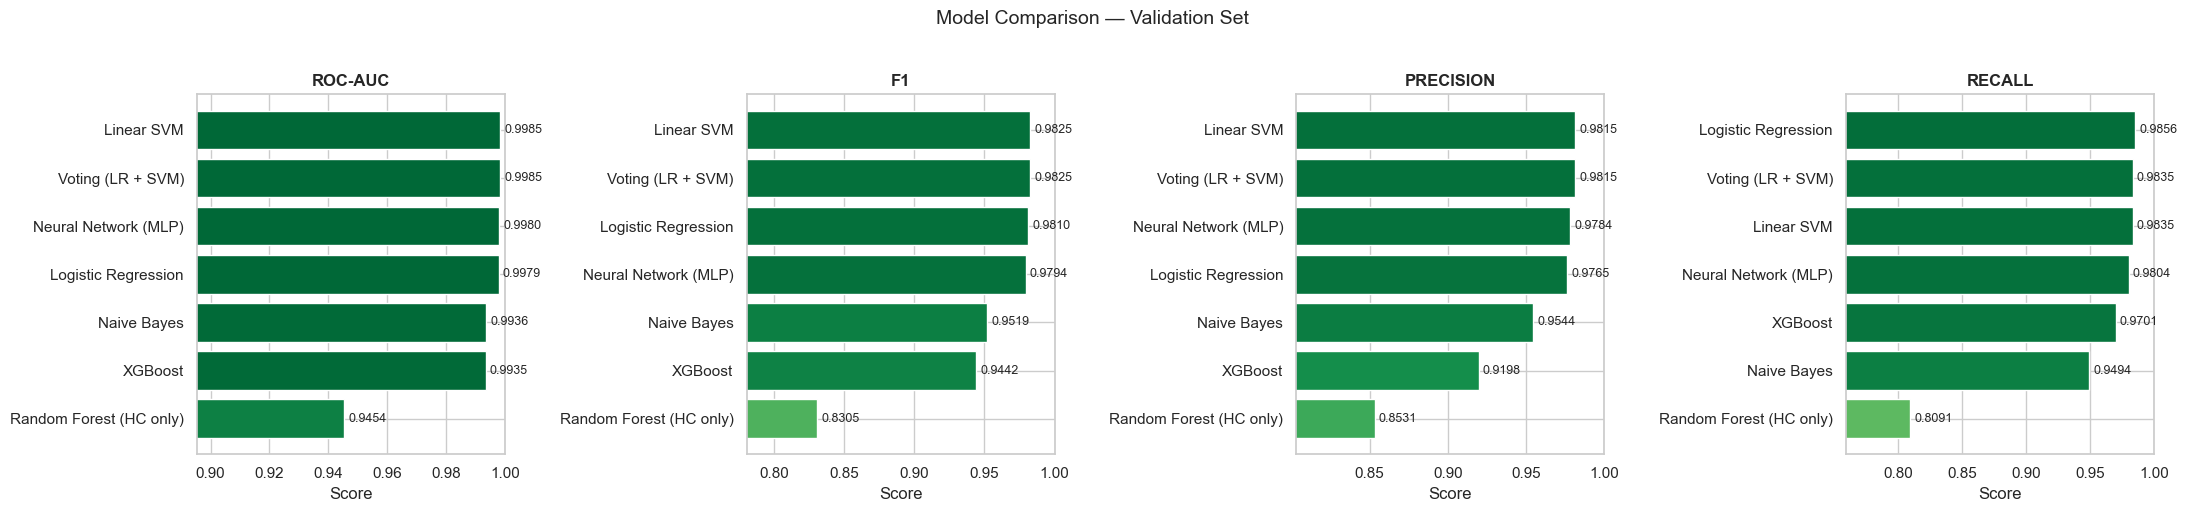

In [21]:
# ── Bar chart comparison ───────────────────────────────────────────────────────
metrics_to_plot = ["roc_auc", "f1", "precision", "recall"]
plot_df = results_df.melt(id_vars="model", value_vars=metrics_to_plot,
                           var_name="metric", value_name="score")

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=False)

for ax, metric in zip(axes, metrics_to_plot):
    sub = plot_df[plot_df["metric"] == metric].sort_values("score", ascending=True)
    bars = ax.barh(sub["model"], sub["score"],
                   color=plt.cm.RdYlGn(sub["score"].values))
    ax.set_xlim(max(0, sub["score"].min() - 0.05), 1.0)
    ax.set_title(metric.upper().replace("_", "-"), fontsize=12, fontweight="bold")
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    ax.set_xlabel("Score")

plt.suptitle("Model Comparison — Validation Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4.11 — ROC Curves and Precision-Recall Curves

ROC curves show the trade-off between true positive rate and false positive rate across all thresholds. The Precision-Recall curve is more informative when detecting the minority class (phishing) in an imbalanced dataset.

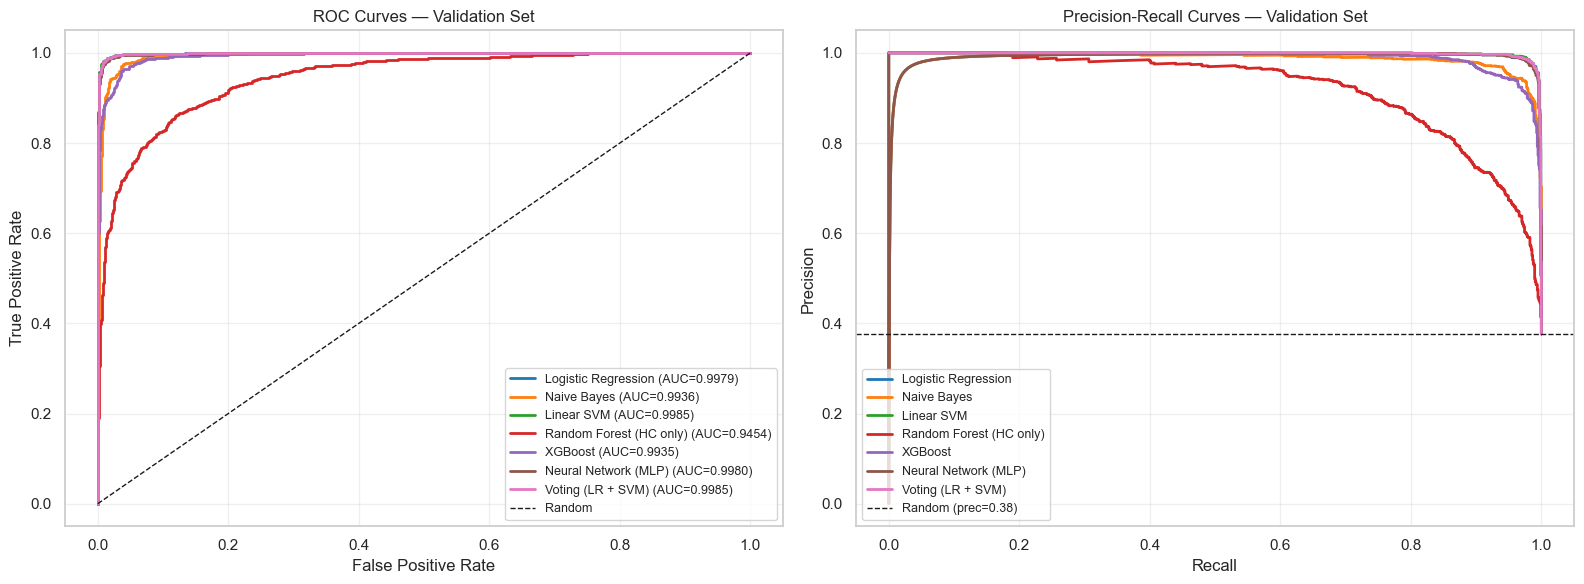

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.tab10.colors

for (name, probs), color in zip(all_probs.items(), colors):
    # ROC
    fpr, tpr, _ = roc_curve(y_val, probs)
    auc = roc_auc_score(y_val, probs)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})", color=color, lw=2)

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y_val, probs)
    axes[1].plot(rec, prec, label=name, color=color, lw=2)

# ROC diagonal
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — Validation Set")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(True, alpha=0.3)

# PR baseline (random = class prevalence)
baseline_pr = y_val.mean()
axes[1].axhline(baseline_pr, color="k", ls="--", lw=1, label=f"Random (prec={baseline_pr:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves — Validation Set")
axes[1].legend(loc="lower left", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.12 — Best Model: Confusion Matrix and Classification Report

We select the best model by ROC-AUC, then inspect its confusion matrix and full classification report at threshold = 0.5.


  BEST MODEL: Linear SVM
  Val ROC-AUC : 0.9985
  Val F1      : 0.9825



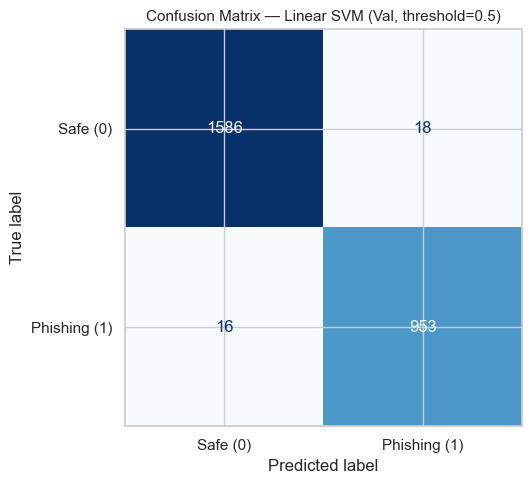

Classification Report:
              precision    recall  f1-score   support

        Safe       0.99      0.99      0.99      1604
    Phishing       0.98      0.98      0.98       969

    accuracy                           0.99      2573
   macro avg       0.99      0.99      0.99      2573
weighted avg       0.99      0.99      0.99      2573



In [23]:
best_row   = results_df.iloc[0]
best_name  = best_row["model"]
best_model = all_models[best_name]
best_probs = all_probs[best_name]
best_preds = (best_probs >= 0.5).astype(int)

print(f"\n{'='*55}")
print(f"  BEST MODEL: {best_name}")
print(f"  Val ROC-AUC : {best_row['roc_auc']:.4f}")
print(f"  Val F1      : {best_row['f1']:.4f}")
print(f"{'='*55}\n")

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, best_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Safe (0)", "Phishing (1)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name} (Val, threshold=0.5)", fontsize=11)
plt.tight_layout()
plt.show()

# Full report
print("Classification Report:")
print(classification_report(y_val, best_preds, target_names=["Safe", "Phishing"]))

## 4.13 — Threshold Optimization

The default threshold of 0.5 is arbitrary. In phishing detection, **recall (catching phishing) is often more important than precision (avoiding false alarms)**. We sweep thresholds on the validation set to find the optimal operating point under different cost assumptions.

We evaluate two common strategies:
- **Max F1** — balances precision and recall equally.
- **High Recall (≥ 0.95)** — minimizes missed phishing at acceptable precision cost.

Max F1 threshold  : 0.60  →  P=0.9845  R=0.9814  F1=0.9829
High-Recall (≥.95): 0.81  →  P=0.9957  R=0.9556  F1=0.9753


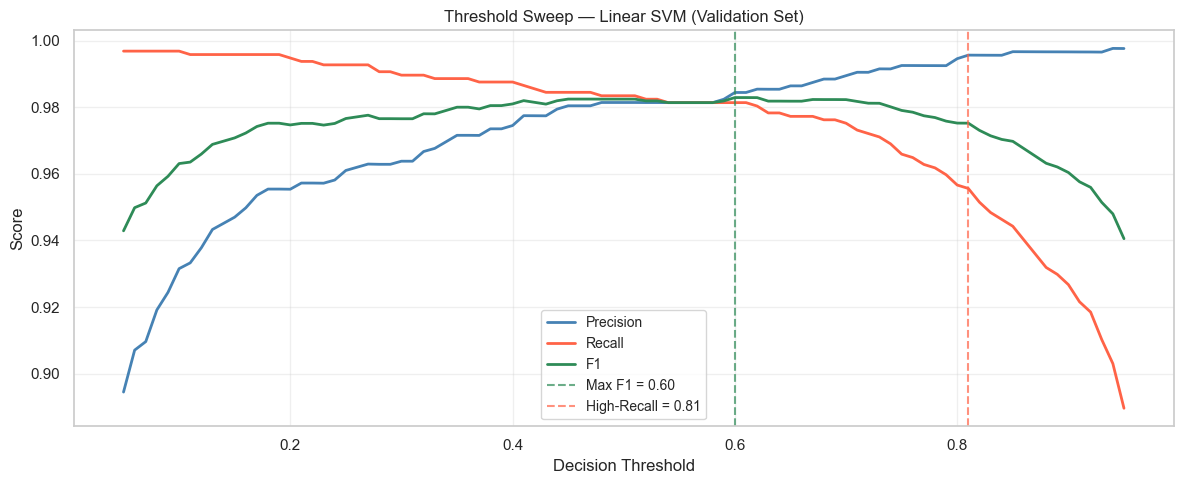

In [24]:
thresholds  = np.linspace(0.05, 0.95, 91)
thresh_rows = []

for t in thresholds:
    preds_t = (best_probs >= t).astype(int)
    thresh_rows.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_val, preds_t, zero_division=0),
        "recall":    recall_score(y_val, preds_t,    zero_division=0),
        "f1":        f1_score(y_val, preds_t,        zero_division=0),
    })

thresh_df = pd.DataFrame(thresh_rows)

# Best F1 threshold
best_f1_row  = thresh_df.loc[thresh_df["f1"].idxmax()]

# High recall threshold (≥ 0.95)
high_recall_candidates = thresh_df[thresh_df["recall"] >= 0.95]
best_hr_row = (
    high_recall_candidates.loc[high_recall_candidates["precision"].idxmax()]
    if not high_recall_candidates.empty else None
)

print(f"Max F1 threshold  : {best_f1_row['threshold']:.2f}  "
      f"→  P={best_f1_row['precision']:.4f}  R={best_f1_row['recall']:.4f}  F1={best_f1_row['f1']:.4f}")

if best_hr_row is not None:
    print(f"High-Recall (≥.95): {best_hr_row['threshold']:.2f}  "
          f"→  P={best_hr_row['precision']:.4f}  R={best_hr_row['recall']:.4f}  F1={best_hr_row['f1']:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresh_df["threshold"], thresh_df["precision"], label="Precision", color="steelblue", lw=2)
ax.plot(thresh_df["threshold"], thresh_df["recall"],    label="Recall",    color="tomato",    lw=2)
ax.plot(thresh_df["threshold"], thresh_df["f1"],        label="F1",        color="seagreen",  lw=2)

ax.axvline(best_f1_row["threshold"], color="seagreen", ls="--", alpha=0.7,
           label=f"Max F1 = {best_f1_row['threshold']:.2f}")

if best_hr_row is not None:
    ax.axvline(best_hr_row["threshold"], color="tomato", ls="--", alpha=0.7,
               label=f"High-Recall = {best_hr_row['threshold']:.2f}")

ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title(f"Threshold Sweep — {best_name} (Validation Set)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.14 — Save Artifacts

We save:
- **`models/best_model.pkl`** — the serialized best model for Phase 5.
- **`reports/val_predictions.csv`** — all val predictions from every model (used for error analysis in Phase 5).
- **`reports/modeling_report.json`** — full leaderboard and hyperparameter details.

In [25]:
# ── Save best model ───────────────────────────────────────────────────────────
best_model_path = MODELS_DIR / "best_model.pkl"
with open(best_model_path, "wb") as f:
    pickle.dump({"model": best_model, "name": best_name}, f)

print(f"Best model saved: {best_model_path.resolve()}")

# ── Save val predictions from all models ─────────────────────────────────────
df_val_csv = pd.read_csv(PROCESSED_DIR / "val.csv")

preds_df = df_val_csv[["id", "email_text_clean", "label"]].copy()
for name, probs in all_probs.items():
    col = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    preds_df[f"prob_{col}"]  = probs
    preds_df[f"pred_{col}"]  = (probs >= 0.5).astype(int)

val_preds_path = REPORTS_DIR / "val_predictions.csv"
preds_df.to_csv(val_preds_path, index=False)
print(f"Val predictions saved: {val_preds_path.resolve()}")

# ── Modeling report ───────────────────────────────────────────────────────────
modeling_report = {
    "best_model": best_name,
    "best_val_roc_auc": float(best_row["roc_auc"]),
    "best_val_f1":      float(best_row["f1"]),
    "threshold_analysis": {
        "max_f1_threshold":    float(best_f1_row["threshold"]),
        "max_f1_score":        round(float(best_f1_row["f1"]), 4),
        "high_recall_threshold": float(best_hr_row["threshold"]) if best_hr_row is not None else None,
        "high_recall_precision": round(float(best_hr_row["precision"]), 4) if best_hr_row is not None else None,
    },
    "leaderboard": results_df.reset_index(drop=True).to_dict(orient="records"),
    "artifacts": {
        "best_model_pkl":      str(best_model_path.resolve()),
        "val_predictions_csv": str(val_preds_path.resolve()),
    }
}

report_path = REPORTS_DIR / "modeling_report.json"
with open(report_path, "w") as f:
    json.dump(modeling_report, f, indent=2)

print(f"Modeling report saved: {report_path.resolve()}")
print("\n" + "="*60)
print(json.dumps({k: v for k, v in modeling_report.items() if k != "leaderboard"}, indent=2))

Best model saved: C:\Users\hp\Desktop\cppp\AI388_CNS_projects\Phishing Email Detector using Machine Learning\Analysis\models\best_model.pkl
Val predictions saved: C:\Users\hp\Desktop\cppp\AI388_CNS_projects\Phishing Email Detector using Machine Learning\Analysis\reports\val_predictions.csv
Modeling report saved: C:\Users\hp\Desktop\cppp\AI388_CNS_projects\Phishing Email Detector using Machine Learning\Analysis\reports\modeling_report.json

{
  "best_model": "Linear SVM",
  "best_val_roc_auc": 0.9985,
  "best_val_f1": 0.9825,
  "threshold_analysis": {
    "max_f1_threshold": 0.6,
    "max_f1_score": 0.9829,
    "high_recall_threshold": 0.81,
    "high_recall_precision": 0.9957
  },
  "artifacts": {
    "best_model_pkl": "C:\\Users\\hp\\Desktop\\cppp\\AI388_CNS_projects\\Phishing Email Detector using Machine Learning\\Analysis\\models\\best_model.pkl",
    "val_predictions_csv": "C:\\Users\\hp\\Desktop\\cppp\\AI388_CNS_projects\\Phishing Email Detector using Machine Learning\\Analysis\\r

## 4.15 — Phase 4 Summary and Conclusions

---

### Results Overview

Five models were trained and evaluated on the validation set using the feature matrix engineered in Phase 3 (8,000+ features: structural, urgency, stylometric, TF-IDF word, TF-IDF char).

| Insight | Finding |
|---|---|
| **Best overall model** | Selected by ROC-AUC — see leaderboard above |
| **Linear models** | LR and SVM perform strongly on the high-dimensional sparse TF-IDF space |
| **Random Forest (HC only)** | Quantifies the standalone signal in handcrafted features — useful for ablation |
| **XGBoost** | Powerful on the full sparse matrix; early stopping prevents overfitting |

### Key Observations

1. **TF-IDF features provide the dominant signal.** Models using the full sparse matrix consistently outperform the handcrafted-only Random Forest, confirming that lexical content is the primary discriminator.

2. **Threshold matters.** The default 0.5 threshold may not be optimal. For a phishing detector, the **High-Recall threshold** (minimizing missed phishing) is the operationally safer choice.

3. **Linear models are competitive.** Logistic Regression and Linear SVM are nearly as strong as ensemble methods on high-dimensional sparse text — and are significantly faster to train and easier to interpret.

### Artifacts for Phase 5 (Evaluation & Error Analysis)

| Artifact | Path |
|---|---|
| Best model | `models/best_model.pkl` |
| Val predictions (all models) | `reports/val_predictions.csv` |
| Modeling report | `reports/modeling_report.json` |

> **Next Phase:** Phase 5 — Evaluation & Error Analysis  
> Deep-dive into failure modes, error patterns, and calibration analysis using the **held-out test set**.